# Iteraciones de Modelado para crear Features
(Datos Originales NFL)
En este notebook iremos explorando qué features se pueden crear con el propósito de mejorar el desempeño del modelo.

## Requisitos para extraer datos

In [1]:
#import gspread

#from google.colab import auth
#from google.colab import drive
#from google.auth import default
#from functools import reduce

#auth.authenticate_user()
#drive.mount('/content/gdrive')
#creds, _ = default()
#gc = gspread.authorize(creds)

# path
#%cd /content/gdrive/MyDrive/'NFL Big Data Bowl 2025'/

## Imports

In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import scipy.spatial as ss
import seaborn as sns
import shap
import warnings

from functools import reduce
from PIL import Image
#from sklearn.linear_model import LogisticRegression
#from sklearn.svm import SVC
#from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale, LabelEncoder
from xgboost import XGBClassifier


Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.


## Configuration

In [3]:
warnings.filterwarnings("ignore")

## Constants

In [4]:
# nb_tracks = -1
nb_tracks = 8

## Functions

In [5]:
def get_path(*args):
  ## Function to get the path
  path = os.path.join(*args)
  return path

def df_report(df):
  shape = df.shape
  info = df.info()
  df.describe()
  return shape, info, df.describe()

## Paths


In [6]:
BASE_PATH = os.path.join(os.getcwd(), '../')
DATA_PATH = get_path(BASE_PATH, "data")
ORIGINAL_DATA_PATH = get_path(DATA_PATH, "original")
GAMES_PATH = get_path(ORIGINAL_DATA_PATH, "games.csv")
PLAYERS_PATH = get_path(ORIGINAL_DATA_PATH, "players.csv")
PLAYS_PATH = get_path(ORIGINAL_DATA_PATH, "plays.csv")
PLAYER_PLAY_PATH = get_path(ORIGINAL_DATA_PATH, "player_play.csv")
TRACKING_PATH = get_path(ORIGINAL_DATA_PATH, "tracking")

## Read Data

In [7]:
games_df = pd.read_csv(GAMES_PATH)
players_df = pd.read_csv(PLAYERS_PATH)
play_df = pd.read_csv(PLAYS_PATH)
#players_play_df = pd.read_csv(PLAYER_PLAY_PATH)

tracking_df = pd.concat([
    pd.read_csv(get_path(TRACKING_PATH, f))for f in os.listdir(TRACKING_PATH)[: nb_tracks]
])

In [62]:
tracking_df.loc[tracking_df.event == 'autoevent_ballsnap', 'event'] = 'ball_snap'
tracking_df.loc[tracking_df.event == 'autoevent_passforward', 'event'] = 'pass_forward'
tracking_df.loc[tracking_df.event == 'autoevent_passinterrupted', 'event'] = 'pass_outcome_incomplete'

In [ ]:
# Para cada jugada obtener:
## line_set antes del snap, el momento del snap esto nos servirá para calcular features
## todos los eventos después del snap, estos tendrán 0 si no corresponden a pass_forward un segundo después. 

In [63]:
all_events_in_tracking_df = tracking_df[tracking_df.event.notna()]

In [64]:
all_events_reduced = all_events_in_tracking_df[
    all_events_in_tracking_df.club=='football'
].groupby(
    ['gameId', 'playId', 'frameType']
).agg(
    {'event': lambda x: list(x)}
).reset_index()

In [65]:
all_events_reduced[all_events_reduced.frameType=='SNAP'].event.value_counts()

event
[ball_snap]      14540
[snap_direct]       49
Name: count, dtype: int64

In [68]:
#all_events_reduced[all_events_reduced.event.apply(lambda x: 'pass_arrived' in x and ("pass_outcome_caught" in x or "pass_outcome_touchdown" in x) )]
plays_with_response_variable = all_events_reduced[
    all_events_reduced.event.apply(
        lambda x: (
            ('pass_forward' in x or 'pass_arrived' in x) and 
            ("pass_outcome_caught" in x or "pass_outcome_touchdown" in x)
        )
    )
]
#all_events_reduced[all_events_reduced.event.apply(lambda x: 'pass_forward' in x and ("pass_outcome_incomplete" in x or "pass_outcome_interception" in x))]
#plays_with_response_variable[plays_with_response_variable.event.apply(lambda x: "pass_forward" not in x)]

In [69]:
plays_with_response_variable

,gameId,playId,frameType,event
0,2022090800,56,AFTER_SNAP,"[pass_forward, pass_arrived, pass_outcome_caug..."
9,2022090800,122,AFTER_SNAP,"[pass_forward, pass_arrived, pass_outcome_caug..."
12,2022090800,167,AFTER_SNAP,"[pass_forward, pass_arrived, pass_outcome_caug..."
18,2022090800,212,AFTER_SNAP,"[pass_forward, pass_arrived, pass_outcome_caug..."
21,2022090800,236,AFTER_SNAP,"[play_action, pass_forward, pass_arrived, pass..."
...,...,...,...,...
43686,2022103100,3189,AFTER_SNAP,"[pass_forward, pass_arrived, pass_outcome_caug..."
43689,2022103100,3213,AFTER_SNAP,"[pass_forward, pass_arrived, pass_outcome_caug..."
43695,2022103100,3275,AFTER_SNAP,"[pass_forward, pass_arrived, pass_outcome_caug..."
43698,2022103100,3304,AFTER_SNAP,"[play_action, pass_forward, pass_arrived, pass..."


In [70]:
# Presnap features: 
# Discrepancy between lineset and snap states. 
# Somehow determine the corresponding matchups. 
all_events_reduced[all_events_reduced.frameType=='BEFORE_SNAP'].event.value_counts()

event
[huddle_break_offense, line_set]                                  5978
[huddle_break_offense, line_set, man_in_motion]                   3692
[line_set]                                                        2329
[huddle_break_offense, line_set, shift]                           1259
[line_set, man_in_motion]                                          472
[huddle_break_offense, man_in_motion, line_set]                    247
[line_set, shift]                                                  161
[huddle_break_offense, line_set, shift, man_in_motion]             116
[huddle_break_offense]                                              54
[man_in_motion, line_set]                                           53
[huddle_break_offense, man_in_motion]                               51
[huddle_break_offense, line_set, shift, shift]                      39
[huddle_break_offense, shift, line_set]                             20
[huddle_start_offense, line_set]                                    19


In [ ]:
all_events_reduced[all_events_reduced.frameType=='SNAP'].event.value_counts()

## Data Analysis

### Functions

In [10]:
def draw_graph(G, pos, color=None):
    plt.figure()
    default_axes = plt.axes(frameon=True)
    edge_labels = nx.get_edge_attributes(G, "weight")
    for key,value in pos.items():
        pos[key] = np.array([value[0], value[1]+0.12])
    #nx.draw_networkx_edge_labels(G, pos = pos, )
    print(edge_labels.values())
    edges = G.edges()
    weights = [G[u][v]['weight'] for u,v in edges]
    nx.draw(G, pos=pos, width=weights, node_color=color)

def get_inverse_distance_graph(team, positions=False):
    weights = ss.distance_matrix(team[['x', 'y']], team[['x', 'y']])
    v = 1/weights#**2
    v[v==np.inf] = 0
    G = nx.from_numpy_array(v)
    if positions:
        pos = team[['x', 'y']].reset_index(drop=True)
        pos['xy'] = pos.apply(lambda x: np.array([x.x, x.y]), axis=1)
        p = pos['xy'].to_dict()
        return G, p
    return G

### Tracking info 
This is important to generate response variable, and data granluarity. 

In [11]:
tracking_df[tracking_df.frameType=='BEFORE_SNAP'].event.value_counts()//23

event
line_set                14447
huddle_break_offense    11490
man_in_motion            4672
shift                    1692
huddle_start_offense       28
timeout_away                1
field_goal_play             1
pass_forward                1
Name: count, dtype: int64

In [12]:
tracking_df[tracking_df.frameType=='AFTER_SNAP'].event.value_counts()//23

event
first_contact                9438
tackle                       9100
pass_forward                 7856
pass_arrived                 6205
handoff                      5211
pass_outcome_caught          4879
pass_outcome_incomplete      2566
play_action                  2471
out_of_bounds                1603
run                           802
qb_sack                       477
touchdown                     396
dropped_pass                  273
pass_tipped                   196
fumble                        193
pass_outcome_interception     171
pass_outcome_touchdown        161
qb_kneel                      153
autoevent_passinterrupted     151
play_submit                   125
fumble_offense_recovered      116
qb_slide                      105
man_in_motion                 103
fumble_defense_recovered       97
shift                          69
lateral                        60
qb_strip_sack                  55
pass_shovel                    44
qb_spike                       21
touchbac

### Visualization Utils

In [13]:
def plot_field(subplots=2, figsize=(15,10)):
  '''Function to plot the football field. '''
  stadium_limit_dimension_y =  (0, 53.3333333)
  stadium_limit_dimension_x = (0, 120)
  color__green = "#586d3d"
  color__white = "#DADADA"
  color__brown = "#663831"
  color__yellow = "#cbb67c"
  text_position = 5
  portery_yards = 6.166667
  numbers = {20:'1 0', 30:'2 0', 40:'3 0', 50:'4 0', 60:'5 0', 70:'4 0', 80:'3 0', 90:'2 0', 100:'1 0'}

  fig, ax = plt.subplots(subplots, figsize=figsize)
  ax[0].set_xlim(stadium_limit_dimension_x)
  ax[0].set_ylim(stadium_limit_dimension_y)
  ax[0].vlines(
      [i for i in range(0, max(stadium_limit_dimension_x), 10)],
      min(stadium_limit_dimension_y),
      max(stadium_limit_dimension_y),
      color=color__white,
      alpha=0.5
  )

  ax[0].vlines(
      [i for i in range(10, max(stadium_limit_dimension_x)-10, 5)],
      min(stadium_limit_dimension_y),
      max(stadium_limit_dimension_y),
      color=color__white,
      alpha=0.3
  )

  vlines2 = [i for i in range(10, max(stadium_limit_dimension_x)-10+1, 1)]
  vlines2_size=1
  ax[0].vlines(
      vlines2,
      min(stadium_limit_dimension_y),
      min(stadium_limit_dimension_y) + vlines2_size,
      color=color__white,
      alpha=0.3
  )
  ax[0].vlines(
      vlines2,
      max(stadium_limit_dimension_y),
      max(stadium_limit_dimension_y) - vlines2_size,
      color=color__white,
      alpha=0.5
  )

  vlines3_size = 0.5
  medium_vlines_pos = (min(stadium_limit_dimension_y) + max(stadium_limit_dimension_y))/2 + portery_yards/2
  medium_vlines_neg = (min(stadium_limit_dimension_y) + max(stadium_limit_dimension_y))/2 - portery_yards/2
  ax[0].vlines(
      vlines2,
      medium_vlines_pos + vlines3_size,
      medium_vlines_pos - vlines3_size,
      color=color__white,
      alpha=0.3
  )
  ax[0].vlines(
      vlines2,
      medium_vlines_neg + vlines3_size,
      medium_vlines_neg - vlines3_size,
      color=color__white,
      alpha=0.3
  )
  for p, n in numbers.items():
    ax[0].text(p, min(stadium_limit_dimension_y) + text_position, n, horizontalalignment='center', verticalalignment='center', color=color__white, rotation=0)
    ax[0].text(p, max(stadium_limit_dimension_y) - text_position, n, horizontalalignment='center', verticalalignment='center', color=color__white, rotation=180)

  triangle_pos = [(i + (i-5))/2 for i in range(20, max(stadium_limit_dimension_x)//2-10+1, 10)]
  ax[0].scatter(triangle_pos, [min(stadium_limit_dimension_y) + text_position]*len(triangle_pos), marker='<', s=10, color=color__white)
  ax[0].scatter(triangle_pos, [max(stadium_limit_dimension_y) - text_position]*len(triangle_pos), marker='<', s=10, color=color__white)

  triangle_pos2 = [(i + (i+5))/2 for i in range(70, max(stadium_limit_dimension_x)-10, 10)]
  ax[0].scatter(triangle_pos2, [min(stadium_limit_dimension_y) + text_position]*len(triangle_pos2), marker='>', s=10, color=color__white)
  ax[0].scatter(triangle_pos2, [max(stadium_limit_dimension_y) - text_position]*len(triangle_pos2), marker='>', s=10, color=color__white)
  ax[0].set_facecolor(color__green)
  ax[0].set_xticks([])
  ax[0].set_yticks([])
  return fig, ax

def draw_graph2(G, ax=None):
    '''Function to plot teams as graphs, with ball.'''
    colors = {-1: "tab:blue", 1:'tab:orange', 0:'brown'}
    node_colors = []
    pos_dict = {}
    for node, attr in G.nodes(data=True):
        team_def = attr["team_deffinition"]
        node_colors.append(colors[team_def])
        pos_dict[node] = np.array([attr["pos_x"],attr["pos_y"]])
    edges = G.edges(data=True)
    weights = [v[-1]['weight'] for v in edges]
    pos = pos_dict
    ec = nx.draw_networkx_edges(G, pos, width=weights, alpha=0.5, ax=ax)
    nc = nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=50, alpha=0.5, ax=ax)

## **Data** Generation

## Feature functions

In [14]:
def influence_function(analysis_unit):
    mean_x = analysis_unit.x + 0.5*analysis_unit.s* np.cos(np.deg2rad(analysis_unit.dir))
    mean_y = analysis_unit.y + 0.5*analysis_unit.s* np.sin(np.deg2rad(analysis_unit.dir))
    
    max_speed = 20 #Max speed proposed in paper over the tracking data
    influence_radius = 3  # Influence in yards of the player. (max dis)
    s_rat = (analysis_unit.s/max_speed)**2
    
    sx = (influence_radius + influence_radius * s_rat) / 2
    sy = (influence_radius - influence_radius * s_rat) / 2
    
    diag_cov_comp1 = sx**2*np.cos(np.deg2rad(analysis_unit.dir))**2
    diag_cov_comp2 = sy**2*np.cos(np.deg2rad(analysis_unit.dir))**2
    
    cov_matrix_det = np.cos(np.deg2rad(analysis_unit.dir))**4 * sx ** 2 * sy ** 2
    
    def matrix_multiplication_result(pos_x, pos_y):
        x_comp = sx ** 2 * np.cos(np.deg2rad(analysis_unit.dir)) ** 2 * (pos_x - mean_x) ** 2
        y_comp = sy ** 2 * np.cos(np.deg2rad(analysis_unit.dir)) ** 2 * (pos_y - mean_y) ** 2
        tot_comp = x_comp + y_comp
        return tot_comp
    influence_sign = analysis_unit.team_deffinition
    
    func = lambda pos_x, pos_y: influence_sign * (1 / np.sqrt(2*np.pi*cov_matrix_det) * np.exp((-1/2)* matrix_multiplication_result(pos_x, pos_y)))
    return func

def influence_function_actual_pos(analysis_unit):
    pos_x = analysis_unit.x
    pos_y = analysis_unit.y
    
    mean_x = analysis_unit.x + 0.5*analysis_unit.s* np.cos(np.deg2rad(analysis_unit.dir))
    mean_y = analysis_unit.y + 0.5*analysis_unit.s* np.sin(np.deg2rad(analysis_unit.dir))
    
    max_speed = 20 #Max speed proposed in paper over the tracking data
    influence_radius = 3  # Influence in yards of the player. (max dis)
    s_rat = (analysis_unit.s/max_speed)**2
    
    sx = (influence_radius + influence_radius * s_rat) / 2
    sy = (influence_radius - influence_radius * s_rat) / 2
    
    diag_cov_comp1 = sx**2*np.cos(np.deg2rad(analysis_unit.dir))**2
    diag_cov_comp2 = sy**2*np.cos(np.deg2rad(analysis_unit.dir))**2
    
    cov_matrix_det = np.cos(np.deg2rad(analysis_unit.dir))**4 * sx ** 2 * sy ** 2
    
    x_comp = sx ** 2 * np.cos(np.deg2rad(analysis_unit.dir)) ** 2 * (pos_x - mean_x) ** 2
    y_comp = sy ** 2 * np.cos(np.deg2rad(analysis_unit.dir)) ** 2 * (pos_y - mean_y) ** 2
    matrix_multiplication_result = x_comp + y_comp
    influence_sign = analysis_unit.team_deffinition
    interaction =  influence_sign * (1 / np.sqrt(2*np.pi*cov_matrix_det) * np.exp((-1/2)* matrix_multiplication_result))
    return interaction

## Feature development

In [15]:
SECONDS = 1
cols = ['gameId', 'playId', 'frameId', 'frameType', 'time', 'playDirection', 'event']

# Selecting only the events (including those where nothing happens).
event_occurence = tracking_df.drop_duplicates(['gameId', 'playId','frameId'])[cols]

# Where there exists no event, lets fill it with none.
event_occurence = event_occurence.fillna('None')
event_occurence.time = pd.to_datetime(event_occurence.time, format='ISO8601')

# Lets get a future event:
event_occurence['current_time'] = event_occurence.time - pd.Timedelta(seconds=SECONDS)
event_occurence['future_event'] = event_occurence.event
future_event_occurence = event_occurence[['gameId', 'playId', 'frameId', 'current_time', 'future_event']]
event_occurence = event_occurence.drop(['current_time', 'future_event'], axis=1)
event_occurence = event_occurence.merge(
    future_event_occurence[['current_time', 'future_event', 'playId', 'gameId']],
    left_on=['time', 'playId', 'gameId'],
    right_on=['current_time', 'playId', 'gameId'],
    how='left'
)

In [16]:
RANDOM_SEED = 42
# Selecting only the most important envents events.
relevant_event_occurence = event_occurence[event_occurence.future_event!='None'].dropna()
# Selecting some of the non-important envents events.
non_relevant_event_occurence = event_occurence[event_occurence.future_event=='None'].sample(
    random_state=RANDOM_SEED, n=relevant_event_occurence.shape[0]//4
)

# Merge all information in one dataframe.
sample_event_occurence = pd.concat([relevant_event_occurence, non_relevant_event_occurence])

# Here we are just mixing everything.
reorgainzed_sample_event_occurence = sample_event_occurence.sample(frac=1, random_state=RANDOM_SEED)
reorgainzed_sample_event_occurence['game_play_frame_id'] = reorgainzed_sample_event_occurence.apply(lambda x: f'{x.gameId}_{x.playId}_{x.frameId}', axis=1)

# IMPORTANT: At this point we have already relevant information on relevant events, and some where nothing happened, instead of focusing in all the tracking ids.

# Now we can simplify what happened in the tracking_df, with the new indexes, creating a reduced_tracking_df.
tracking_df['game_play_frame_id'] = tracking_df.gameId.astype('str') + '_' + tracking_df.playId.astype('str') + '_' + tracking_df.frameId.astype('str')
reduced_tracking_df = tracking_df[tracking_df.game_play_frame_id.isin(reorgainzed_sample_event_occurence.game_play_frame_id)]
reduced_tracking_df['game_play'] = reduced_tracking_df.gameId.astype('str') + '_' + reduced_tracking_df.playId.astype('str')

#### Relevant df: reduced_tracking_df
# We can add context of the play, focusing only on the relevant plays, where the selected events happened.
play_df['game_play'] = play_df.gameId.astype('str') + '_' + play_df.playId.astype('str')
reduced_play_df = play_df[play_df.game_play.isin(reduced_tracking_df['game_play'])]

reduced_play_df['team_deffinition'] = reduced_play_df.apply(lambda x: {x.possessionTeam: 1, x.defensiveTeam: -1}, axis=1)
reduced_play_df['gameClock_time'] = reduced_play_df.gameClock.str.split(':').apply(lambda x: int(x[0])*60 + int(x[1]))
reduced_play_df['preSnapScore_difference'] = reduced_play_df['preSnapHomeScore'] - reduced_play_df['preSnapVisitorScore']
reduced_play_df['receiverAlignment_0'] = reduced_play_df.receiverAlignment.fillna('0x0').str.split('x').apply(lambda x: x[0])
reduced_play_df['receiverAlignment_1'] = reduced_play_df.receiverAlignment.fillna('0x0').str.split('x').apply(lambda x: x[1])

reduced_play_columns = [
    'quarter',
    'down',
    'yardsToGo',
    'yardlineNumber',
    'absoluteYardlineNumber',
    'preSnapHomeTeamWinProbability',
    'preSnapVisitorTeamWinProbability',
    'gameClock_time',
    'receiverAlignment_0',
    'receiverAlignment_1',
    'game_play',
    'team_deffinition',
]

reduced_play_df = reduced_play_df[reduced_play_columns]

#### Relevant df:  reduced_play_df
# we can include player information to the reduced_tracking_df
reduced_tracking_w_player_info_df = reduced_tracking_df.merge(players_df, on='nflId', how='left')[
    ['nflId','x', 'y','club', 's', 'a', 'dir','event', 'weight', 'position', 'dis', 'o', 'game_play_frame_id', 'game_play']
]
reduced_tracking_w_player_info_df = reduced_tracking_w_player_info_df.merge(reduced_play_df[['game_play', 'team_deffinition']], on='game_play', how='left')
reduced_tracking_w_player_info_df['team_deffinition'] = reduced_tracking_w_player_info_df.apply(
    lambda row: row.team_deffinition.get(row.club), axis=1
)
reduced_tracking_w_player_info_df.loc[reduced_tracking_w_player_info_df.club=='football', 'weight'] =  1.11

# Encode position
lb_player_position = LabelEncoder()
lb_player_position.fit(reduced_tracking_w_player_info_df.position.unique())
reduced_tracking_w_player_info_df["encoded_position"] = lb_player_position.transform(reduced_tracking_w_player_info_df.position)
reduced_tracking_w_player_info_df.loc[reduced_tracking_w_player_info_df.fillna(0).dir==90, 'dir'] = 91
reduced_tracking_w_player_info_df.loc[reduced_tracking_w_player_info_df.fillna(0).dir==270, 'dir'] = 269

reduced_tracking_w_player_info_df['current_position_influence'] = reduced_tracking_w_player_info_df.apply(influence_function_actual_pos, axis=1)
reduced_tracking_w_player_info_df.drop(columns=['position'], inplace=True)

In [ ]:
with open('../models/models1/lb_player_position.pkl', 'wb') as f:
    pickle.dump(lb_player_position, f)

In [ ]:
# For each player we can compute their physical values:
reduced_tracking_w_player_info_df['action'] = reduced_tracking_w_player_info_df.weight*reduced_tracking_w_player_info_df.s*reduced_tracking_w_player_info_df.dis
reduced_tracking_w_player_info_df['ke'] = 1/2*reduced_tracking_w_player_info_df.weight*reduced_tracking_w_player_info_df.s**2
reduced_tracking_w_player_info_df['p'] = reduced_tracking_w_player_info_df.weight*reduced_tracking_w_player_info_df.s
reduced_tracking_w_player_info_df['px'] = reduced_tracking_w_player_info_df.weight*reduced_tracking_w_player_info_df.s*np.cos(np.deg2rad(reduced_tracking_w_player_info_df.dir))
reduced_tracking_w_player_info_df['py'] = reduced_tracking_w_player_info_df.weight*reduced_tracking_w_player_info_df.s*np.sin(np.deg2rad(reduced_tracking_w_player_info_df.dir))
reduced_tracking_w_player_info_df['fx'] = reduced_tracking_w_player_info_df.weight*reduced_tracking_w_player_info_df.a*np.cos(np.deg2rad(reduced_tracking_w_player_info_df.dir))
reduced_tracking_w_player_info_df['fy'] = reduced_tracking_w_player_info_df.weight*reduced_tracking_w_player_info_df.a*np.sin(np.deg2rad(reduced_tracking_w_player_info_df.dir))
reduced_tracking_w_player_info_df['f'] = reduced_tracking_w_player_info_df.weight*reduced_tracking_w_player_info_df.a
reduced_tracking_w_player_info_df['work'] = reduced_tracking_w_player_info_df.f*reduced_tracking_w_player_info_df.dis

# This can be done at a general scope
general_reduced_tracking_w_player_info_df = reduced_tracking_w_player_info_df.groupby('game_play_frame_id').agg(
    {'dis':'sum', 'ke': 'sum', 'f': 'sum', 'fx': 'sum', 'fy': 'sum', 'p':'sum', 'px': 'sum', 'py':'sum','work': 'sum', 'action':'sum', 'x': 'mean', 'y':'mean'}
)
team_reduced_tracking_w_player_info_df = reduced_tracking_w_player_info_df[
    reduced_tracking_w_player_info_df.club != 'football'
].groupby(['game_play_frame_id', 'club']).agg(
    {'dis':'sum', 
     'ke': 'sum', 
     'f': 'sum', 
     'fx': 'sum', 
     'fy': 'sum', 
     'p':'sum', 
     'px': 'sum', 
     'py':'sum', 
     'work': 'sum',
     'action':'sum', 
     'x': 'mean',
     'y':'mean', 
     'game_play': 'first',
     'team_deffinition': 'first', 
     'current_position_influence': 'mean',
    }
).reset_index()

# Or as a team scope
team_reduced_tracking_w_player_info_df_possesion = team_reduced_tracking_w_player_info_df[
    team_reduced_tracking_w_player_info_df.team_deffinition == 1
].drop(['club', 'game_play', 'team_deffinition'], axis=1).set_index('game_play_frame_id')
team_reduced_tracking_w_player_info_df_defensive = team_reduced_tracking_w_player_info_df[
    team_reduced_tracking_w_player_info_df.team_deffinition == -1
].drop(['club', 'game_play', 'team_deffinition'], axis=1).set_index('game_play_frame_id')

team_reduced_tracking_w_player_info_df_difference = (
    team_reduced_tracking_w_player_info_df_possesion -
    team_reduced_tracking_w_player_info_df_defensive
)

team_reduced_tracking_w_player_info_df_difference = team_reduced_tracking_w_player_info_df_difference.rename(
    columns={col: f'{col}__difference' for col in team_reduced_tracking_w_player_info_df_difference.columns}
)
general_reduced_tracking_w_player_info_df = general_reduced_tracking_w_player_info_df.rename(
    columns={col: f'{col}__general' for col in general_reduced_tracking_w_player_info_df.columns}
)

In [ ]:
most_influence_defensive = reduced_tracking_w_player_info_df[reduced_tracking_w_player_info_df.team_deffinition==-1].sort_values('current_position_influence', ascending=True).groupby('game_play_frame_id').agg(
    {'encoded_position': 'first', 'current_position_influence': 'first'}
).rename(columns={'encoded_position':'most_influence_encoded_position_defensive', 'current_position_influence':'most_influence_defensive',})

most_influence_possesion = reduced_tracking_w_player_info_df[reduced_tracking_w_player_info_df.team_deffinition==1].sort_values('current_position_influence', ascending=False).groupby('game_play_frame_id').agg(
    {'encoded_position': 'first', 'current_position_influence': 'first'}
).rename(columns={'encoded_position':'most_influence_encoded_position_possesion', 'current_position_influence':'most_influence_possesion',})

In [ ]:
def get_metrics_distance_between_team_players(df):
  distances = ss.distance_matrix(
      df[df.team_deffinition == -1][['x','y']],
      df[df.team_deffinition == 1][['x', 'y']]
  )
  distance_metrics = {
      'distance_between_teams_min': np.min(distances),
      'distance_between_teams_max': np.max(distances),
      'distance_between_teams_mean': np.mean(distances),
      'distance_between_teams_std': np.std(distances),
  }
  return distance_metrics

general_vs_team_distance_metrics = reduced_tracking_w_player_info_df.groupby('game_play_frame_id').apply(get_metrics_distance_between_team_players)
general_vs_team_distance_metrics = pd.json_normalize(general_vs_team_distance_metrics).set_index(general_vs_team_distance_metrics.index)

In [ ]:
# Metrics of the ball position relative to the teams can also be computed:
football_info_df = reduced_tracking_w_player_info_df[reduced_tracking_w_player_info_df.club == 'football'].set_index('game_play_frame_id')
football_info_df.drop(['nflId', 'dir', 'event', 'weight', 'encoded_position', 'o', 'action', 'ke', 'fx', 'fy', 'f', 'px', 'py', 'work', 'club'], axis=1, inplace=True)
football_info_df['distance_general'] = (
    (general_reduced_tracking_w_player_info_df.x__general - football_info_df.x) ** 2 + 
    (general_reduced_tracking_w_player_info_df.y__general - football_info_df.y) ** 2
)
football_info_df['distance_possesion_team'] = (
    (football_info_df.x - team_reduced_tracking_w_player_info_df_possesion.x) ** 2 + 
    (football_info_df.y - team_reduced_tracking_w_player_info_df_possesion.y) ** 2
)
football_info_df['distance_defensive_team'] = (
    (football_info_df.x - team_reduced_tracking_w_player_info_df_defensive.x) ** 2 + 
    (football_info_df.y - team_reduced_tracking_w_player_info_df_defensive.y) ** 2
)
all_players_reduced_tracking_positions = reduced_tracking_w_player_info_df[
    reduced_tracking_w_player_info_df.club != 'football'
].set_index('game_play_frame_id')[['x', 'y', 'encoded_position', 'game_play', 'club']]

all_players_reduced_tracking_positions['distance_to_football'] = list(
    (football_info_df.x-all_players_reduced_tracking_positions.x)**2 + 
    (football_info_df.y-all_players_reduced_tracking_positions.y)**2
)
all_players_reduced_tracking_positions.reset_index(inplace=True)

all_players_reduced_tracking_positions = all_players_reduced_tracking_positions.merge(
    reduced_play_df[['game_play', 'team_deffinition']], on='game_play', how='left'
)
all_players_reduced_tracking_positions['team_deffinition'] = all_players_reduced_tracking_positions.apply(
    lambda row: row.team_deffinition[row.club], axis=1
)

min_distances_to_ball = all_players_reduced_tracking_positions.sort_values(
    ['game_play_frame_id', 'distance_to_football', 'team_deffinition']
).drop_duplicates(
    ['game_play_frame_id', 'team_deffinition'], keep='first'
)

min_distances_to_ball_defensive = min_distances_to_ball[
    min_distances_to_ball.team_deffinition==-1
].set_index('game_play_frame_id')[['encoded_position', 'distance_to_football']]

min_distances_to_ball_possesion = min_distances_to_ball[
    min_distances_to_ball.team_deffinition==1
].set_index('game_play_frame_id')[['encoded_position', 'distance_to_football']]

min_distances_to_ball_defensive.rename(
    columns={col: f'min_{col}_defensive' for col in min_distances_to_ball_defensive.columns}, inplace=True
)
min_distances_to_ball_possesion.rename(
    columns={col: f'min_{col}_possesion' for col in min_distances_to_ball_possesion.columns}, inplace=True
)

football_info_df.rename(columns={col:f'football_{col}' for col in football_info_df.columns}, inplace=True)
football_info_df.drop(['football_team_deffinition'], axis=1, inplace=True)

## Graph functions

In [ ]:
# We can create a graph
def angle_matrix(x, y, p=2, threshold=1000000):
  x = np.asarray(x)
  y = np.asarray(y)
  x = x[:,np.newaxis,:]
  y = y[np.newaxis,:,:]
  x_y = y-x
  arctan_vals = np.arctan2(x_y[:,:,1], x_y[:,:,0])*180/np.pi
  arctan_vals[arctan_vals < 0] = arctan_vals[arctan_vals < 0] + 360
  return arctan_vals

def get_analysis_unit_without_ball(analysis_unit):
  analysis_unit_without_ball = analysis_unit[analysis_unit.club!='football']
  return analysis_unit_without_ball

def get_look_matrix(analysis_unit, not_ball=True):
  analysis_unit = analysis_unit.copy()
  if not_ball:
    analysis_unit = get_analysis_unit_without_ball(analysis_unit)
  # Get the analysis unit without the ball.

  # Get the angle matrix, depending in positions.
  angles_according_to_position = angle_matrix(
      analysis_unit[['x', 'y']],
      analysis_unit[['x', 'y']]
      )
  # Compare if positions are aligned to orientation or direction.
  angles_according_to_position_o = angles_according_to_position - np.asarray(analysis_unit.o)
  angles_according_to_position_dir = angles_according_to_position - np.asarray(analysis_unit.dir)
  # Normalize the direction with cosine
  # (if aligned then 1, if not then 0, and any values between that, also negative alignment is possible).
  look_o = np.cos(np.deg2rad(angles_according_to_position_o)) # Relevance depending in direction
  look_dir = np.cos(np.deg2rad(angles_according_to_position_dir))
  # Sum the contribution of both alingments, at 50%50.
  look = (look_o + look_dir)/2
  look = np.nan_to_num(look, nan=0)
  look = np.matrix.transpose(look)
  return look

def get_inverse_distance_matrix_weighted_by_look(analysis_unit, not_ball=False):
  inverse_distance_matrix = get_inverse_distance_matrix(analysis_unit, not_ball=not_ball, power=1)
  look = get_look_matrix(analysis_unit, not_ball=not_ball)
  #inverse_distance_matrix_weighted = inverse_distance_matrix + 10*look
  inverse_distance_matrix_weighted = inverse_distance_matrix*look
  return inverse_distance_matrix_weighted

def get_team_positions(analysis_unit, not_ball=True):
  analysis_unit = analysis_unit.copy()
  if not_ball:
    analysis_unit = get_analysis_unit_without_ball(analysis_unit)
  pos = analysis_unit[['x', 'y']].reset_index(drop=True)
  pos['xy'] = pos.apply(lambda x: np.array([x.x, x.y]), axis=1)
  pos = pos['xy'].to_dict()
  return pos

def get_inverse_distance_matrix(analysis_unit, power=1, not_ball=True):
  analysis_unit = analysis_unit.copy()
  if not_ball:
    analysis_unit = get_analysis_unit_without_ball(analysis_unit)
  # Get distance matrix
  unit_distance_matrix = ss.distance_matrix(
      analysis_unit[['x', 'y']],
      analysis_unit[['x', 'y']])
  # Divide 1 over the values by a power
  inverse_distance_matrix = 1/unit_distance_matrix**(power)
  # Replace infinite with 0
  inverse_distance_matrix[inverse_distance_matrix==np.inf] = 0
  inverse_distance_matrix = np.nan_to_num(inverse_distance_matrix, nan=0)
  return inverse_distance_matrix

def get_team_graph(analysis_unit, not_ball=False):
  matrix = get_inverse_distance_matrix_weighted_by_look(analysis_unit, not_ball=not_ball)
  G = nx.from_numpy_array(matrix, create_using=nx.MultiDiGraph()) # Must be multidigraph
  return G

def get_team_graph_no_negative(analysis_unit, not_ball=False):
  matrix = get_inverse_distance_matrix_weighted_by_look(analysis_unit, not_ball=not_ball)
  matrix[matrix<0] = 0
  G = nx.from_numpy_array(matrix, create_using=nx.MultiDiGraph()) # Must be multidigraph
  return G

def get_graph_with_nodes_attrs(analysis_unit, not_ball=False, no_negatives=False):
  if no_negatives:
    g = get_team_graph_no_negative(analysis_unit, not_ball=not_ball)
  else:
    g = get_team_graph(analysis_unit, not_ball=False)

  nx.set_node_attributes(g, analysis_unit.reset_index(drop=True).action.to_dict(), 'action')
  nx.set_node_attributes(g, analysis_unit.reset_index(drop=True).ke.to_dict(), 'ke')
  nx.set_node_attributes(g, analysis_unit.reset_index(drop=True).p.to_dict(), 'p')
  nx.set_node_attributes(g, analysis_unit.reset_index(drop=True).f.to_dict(), 'f')
  nx.set_node_attributes(g, analysis_unit.reset_index(drop=True).work.to_dict(), 'work')
  nx.set_node_attributes(g, analysis_unit.reset_index(drop=True).team_deffinition.fillna(0).to_dict(), 'team_deffinition')
  nx.set_node_attributes(g, analysis_unit.reset_index(drop=True).x.to_dict(), 'pos_x')
  nx.set_node_attributes(g, analysis_unit.reset_index(drop=True).y.to_dict(), 'pos_y')
  nx.set_node_attributes(g, analysis_unit.reset_index(drop=True).y.to_dict(), 'encoded_position')

  # Graph computables
  #nx.set_node_attributes(g, nx.centrality.trophic_levels(g, weight='weight'), 'trophic_level')
  #nx.set_node_attributes(g, dict(g.degree(weight='weight')), 'degree')
  #nx.set_node_attributes(g, nx.betweenness_centrality(g, weight='weight'), 'betweenness_centrality')


  #additional_network_features = pd.DataFrame()
  #additional_network_features['betweenness_centrality'] = nx.centrality.betweenness_centrality(g, weight='weight')
  #additional_network_features['percolation_centrality_action'] = nx.centrality.percolation_centrality(g, weight='weight', attribute='action')
  #additional_network_features['percolation_centrality_ke'] = nx.centrality.percolation_centrality(g, weight='weight', attribute='ke')
  #additional_network_features['percolation_centrality_p'] = nx.centrality.percolation_centrality(g, weight='weight', attribute='p')
  #additional_network_features['percolation_centrality_f'] = nx.centrality.percolation_centrality(g, weight='weight', attribute='f')
  #additional_network_features['percolation_centrality_work'] = nx.centrality.percolation_centrality(g, weight='weight', attribute='work')

  #additional_network_features['betweeness_residual_action_percolation'] = additional_network_features.betweenness_centrality - additional_network_features.percolation_centrality_action
  #additional_network_features['betweeness_residual_ke_percolation'] = additional_network_features.betweenness_centrality - additional_network_features.percolation_centrality_ke
  #additional_network_features['betweeness_residual_p_percolation'] = additional_network_features.betweenness_centrality - additional_network_features.percolation_centrality_p
  #additional_network_features['betweeness_residual_f_percolation'] = additional_network_features.betweenness_centrality - additional_network_features.percolation_centrality_f
  #additional_network_features['betweeness_residual_work_percolation'] = additional_network_features.betweenness_centrality - additional_network_features.percolation_centrality_work

  #additional_network_features.drop(
  #    ['percolation_centrality_action',
  #    'percolation_centrality_ke',
  #    'percolation_centrality_p',
  #    'percolation_centrality_f',
  #    'percolation_centrality_work'], axis=1, inplace=True)

  #for col in additional_network_features.columns:
  #  nx.set_node_attributes(g, additional_network_features[col].to_dict(), col)
  return g

def get_laplacian_matrix(g, weight='weight'):
    # Laplacian = adjacency - degree
    adj_matrix = nx.adjacency_matrix(g, weight=weight).toarray()
    degree_matrix = np.diag(np.array((g.degree(weight=weight)))[:,1])
    laplacian_matrix = adj_matrix - degree_matrix
    return laplacian_matrix

# Embedding fgsd:
def get_fgsd_embedding(g, replicability_nb=3):
  laplacian_matrix = get_laplacian_matrix(g, weight='weight') 
  inverted_laplacian_matrix = np.linalg.pinv(laplacian_matrix)
  ones = np.ones(laplacian_matrix.shape[0])
  S = np.outer(np.diag(inverted_laplacian_matrix), ones) + np.outer(ones, np.diag(inverted_laplacian_matrix)) - 2 * inverted_laplacian_matrix
  hist, _ = np.histogram(S.flatten(), bins=22*replicability_nb)
  hist = hist/hist.sum()
  return hist

def get_laplacian_embedding(g, replicability_nb=2):
  laplacian_matrix = get_laplacian_matrix(g, weight='weight') # Laplacian = adjacency - degree
  hist, _ = np.histogram(laplacian_matrix.flatten(), bins=22*replicability_nb)
  hist = hist/hist.sum()
  return hist

def get_adjacent_embedding(g, replicability_nb=2):
  laplacian_matrix = nx.adjacency_matrix(g, weight='weight').toarray() # Laplacian = adjacency - degree
  hist, _ = np.histogram(laplacian_matrix.flatten(), bins=22*replicability_nb)
  hist = hist/hist.sum()
  return hist

# Embedding feather
def get_feathergraph_embedding(g):
  adjacency_matrix = nx.adjacency_matrix(g, weight='weight').toarray()
  degree_inverse = np.diag(1/np.array((g.degree(weight='weight')))[:,1])
  normalized_adjacency_matrix = degree_inverse.dot(adjacency_matrix)

  node_features = pd.DataFrame(
      dict(g.nodes(data=True))
  ).T

  scaled_node_features = pd.DataFrame(
      scale(node_features, axis=0),
      index=node_features.index,
      columns=node_features.columns
  )
  #scaled_node_features = node_features

  theta = np.linspace(np.pi//2, 2*np.pi+np.pi//2, 360//24)
  outer_scaled_node_features = np.outer(scaled_node_features, theta).reshape(g.number_of_nodes(), -1)
  outer_scaled_node_features_transformed = np.concatenate([np.cos(outer_scaled_node_features), np.sin(outer_scaled_node_features)], axis=1)
  modified_outer_scaled_node_features_transformed = outer_scaled_node_features_transformed.copy()

  feature_blocks = []
  for _ in range(5):
    modified_outer_scaled_node_features_transformed = normalized_adjacency_matrix.dot(modified_outer_scaled_node_features_transformed)
    feature_blocks.append(modified_outer_scaled_node_features_transformed)

  feature_blocks = np.concatenate(feature_blocks, axis=1)
  feather_feature_blocks =  np.mean(feature_blocks, axis=0)
  return feather_feature_blocks


## Graph construction

In [ ]:
#usample = reduced_tracking_w_player_info_df.game_play_frame_id.sample(100).unique()
#sample = reduced_tracking_w_player_info_df[reduced_tracking_w_player_info_df.game_play_frame_id.isin(usample)]
#graphs = reduced_tracking_w_player_info_df.groupby('game_play_frame_id').apply(get_graph_with_nodes_attrs, no_negatives=True)
#graphs = sample.groupby('game_play_frame_id').apply(get_graph_with_nodes_attrs, no_negatives=True)
#graphs2 = sample.groupby('game_play_frame_id').apply(get_graph_with_nodes_attrs, no_negatives=True)

In [21]:
#graphs.to_pickle('../data/processed/graphs.pkl')
graphs = pd.read_pickle('../data/processed/graphs.pkl')

In [22]:
# sample_graphs = graphs.sample(10)

# sample_graphs.apply(lambda x: nx.centrality.betweenness_centrality(x, weight='weight'))
# sample_graphs.apply(lambda x: nx.centrality.load_centrality(x, weight='weight'))
# sample_graphs.apply(lambda x: nx.centrality.harmonic_centrality(x, distance='weight'))
# sample_graphs.apply(lambda x: nx.assortativity.average_neighbor_degree(x, weight='weight'))
# sample_graphs.apply(lambda x: nx.assortativity.average_degree_connectivity(x, weight='weight'))
# #sample_graphs.apply(lambda x: nx.panther_similarity(x, 22)) # problems
# sample_graphs.apply(lambda x: nx.pagerank(x, weight='weight'))
# #sample_graphs.apply(lambda x: nx.centrality.trophic_levels(x, weight='weight')) # Problems

# Compute one for each different attribute
#sample_graphs.apply(lambda x: nx.assortativity.numeric_assortativity_coefficient(x, attribute='team_deffinition'))
#sample_graphs.apply(lambda x: nx.assortativity.numeric_assortativity_coefficient(x, attribute='p'))
#sample_graphs.apply(lambda x: nx.assortativity.degree_assortativity_coefficient(x, weight='weight'))

In [23]:
# adjacent_embeddings = graphs.apply(get_adjacent_embedding)

# adjacent_embeddings_df = pd.DataFrame(
#     np.concatenate(adjacent_embeddings.to_numpy()).reshape(adjacent_embeddings.shape[0], len(adjacent_embeddings[0])),
#     index=adjacent_embeddings.index,
#     columns=[f'adjacent_{i}' for i in range(len(adjacent_embeddings[0]))],
# )
# del adjacent_embeddings

In [24]:
feather_embeddings = graphs.apply(get_feathergraph_embedding)

feather_embeddings_df = pd.DataFrame(
    np.concatenate(feather_embeddings.to_numpy()).reshape(feather_embeddings.shape[0], len(feather_embeddings[0])),
    index=feather_embeddings.index,
    columns=[f'feather_embeddings_{i}' for i in range(len(feather_embeddings[0]))],
)
del feather_embeddings

In [25]:
# fgsd_embeddings = graphs.apply(get_fgsd_embedding)

# fgsd_embeddings_df = pd.DataFrame(
#     np.concatenate(fgsd_embeddings.to_numpy()).reshape(fgsd_embeddings.shape[0], len(fgsd_embeddings[0])),
#     index=fgsd_embeddings.index,
#     columns=[f'fgsd_embeddings_{i}' for i in range(len(fgsd_embeddings[0]))],
# )
# del fgsd_embeddings

In [26]:
# graph_features = pd.DataFrame()
# graph_features['graph_flow_hierarchy'] = graphs.apply(lambda x: nx.flow_hierarchy(x, weight='weight'))
# graph_features['graph_reciprocity'] = graphs.apply(lambda x: nx.reciprocity(x))

In [27]:
#nx.community.louvain_communities(g, weight='weight', seed=RANDOM_SEED)
#sample_graphs.apply(lambda x: nx.dominating_set(x, start_with=22))

#sns.heatmap(nx.degree_mixing_matrix(g, weight='weight',x='out'))

In [28]:
# Comunidades entre el grafo.
#nx.community.louvain_communities(g, weight='weight', seed=RANDOM_SEED)

## Context

In [17]:
# Lastly we use additional context
current_event_stuff = reorgainzed_sample_event_occurence.set_index('game_play_frame_id')[['frameType', 'playDirection', 'future_event']]
current_event_stuff['frameType'] = current_event_stuff.frameType.map({'BEFORE_SNAP': 0, 'AFTER_SNAP': 1, 'SNAP':0.5})
current_event_stuff['playDirection'] = current_event_stuff.playDirection.map({'right': 0, 'left': 1})
#current_event_stuff.rename(columns={'future_event': 'y'}).y.to_pickle('../data/processed/response_var.pkl')

In [18]:
result_df_list = [
    current_event_stuff, # Contains response var
    team_reduced_tracking_w_player_info_df_difference,
    general_reduced_tracking_w_player_info_df,
    min_distances_to_ball_defensive,
    min_distances_to_ball_possesion,
    football_info_df,
    general_vs_team_distance_metrics,
    #fgsd_embeddings_df,
    #adjacent_embeddings_df,
    most_influence_defensive, 
    most_influence_possesion,
    feather_embeddings_df,
    #graph_features,
]
all_features = reduce(lambda  left, right: pd.merge(left,right, left_index=True, right_index=True, how='left'), result_df_list)

In [19]:
X, y = all_features.select_dtypes('number'), all_features.future_event

X = X[list(~y.isin(y.value_counts()[y.value_counts()==1].index))]
y = y[~y.isin(y.value_counts()[y.value_counts()==1].index)]
d1 = {f'{col}':f'{col}' for col in y.unique() if "pass_forward" in col} 
d2 = {f'{col}':f'Other' for col in y.unique() if "pass_forward" not in col}
d1.update(d2)
y_pass_forward = y.map(d1)

In [20]:
y

game_play_frame_id
2022091111_166_88            man_in_motion
2022101700_3617_46                line_set
2022102300_765_149                    None
2022101600_2872_145          out_of_bounds
2022101300_675_124               ball_snap
                              ...         
2022100901_3785_141          first_contact
2022103100_874_27                 line_set
2022091200_2546_34                    None
2022091113_923_123     pass_outcome_caught
2022091808_565_62                 line_set
Name: future_event, Length: 109111, dtype: object

In [21]:
import pickle
with open('../data/processed/target_1s.pkl', 'wb') as f:
    pickle.dump(y, f)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_pass_forward, test_size=0.2, random_state=RANDOM_SEED, stratify=y_pass_forward
)

lb = LabelEncoder()
lb.fit(y_train)
y_train = lb.transform(y_train)
y_test = lb.transform(y_test)

In [84]:
with open('../models/models1/lb.pkl', 'wb') as f:
    pickle.dump(lb, f)

In [33]:
from sklearn.decomposition import PCA
x_train_graph_embeddings = X_train[[col for col in X_train.columns if "embedding" in col]].fillna(-1)
pca_model = PCA(n_components=100)
pca_model.fit(x_train_graph_embeddings)
real_n_components = (abs(np.gradient(np.log(pca_model.explained_variance_))) > 0.1).sum()
pca_model = PCA(n_components=real_n_components*2)
pca_model.fit(x_train_graph_embeddings)

PCA(n_components=36)

In [85]:
with open('../models/models1/pca.pkl', 'wb') as f:
    pickle.dump(pca_model, f)

In [34]:
def get_pca_feather_embeddings(pca, x):
    feather_embeddings_columns = [col for col in x.columns if "embedding" in col]
    feather_embeddings =  x[feather_embeddings_columns].fillna(-1)
    pca_feather_embeddings = pca.transform(feather_embeddings)
    columns = [f'pca_feather_embedding_{i}' for i in range(pca_feather_embeddings.shape[1])]
    df_pca_feather_embeddings = pd.DataFrame(pca_feather_embeddings, index=x.index, columns=columns)
    x.drop(columns=feather_embeddings_columns, inplace=True)
    new_x = pd.merge(x, df_pca_feather_embeddings, left_index=True, right_index=True, how='left')
    return new_x    

In [35]:
X_train = get_pca_feather_embeddings(pca=pca_model, x=X_train)
X_test = get_pca_feather_embeddings(pca=pca_model, x=X_test)

In [36]:
scale_pos_weight = (y_train==0).sum()/(y_train==1).sum()

In [37]:
model_labels_dict = {val: lb.inverse_transform([val])[0] for val in pd.Series(y_test).unique()}
model_labels = [model_labels_dict[element] for element in sorted(model_labels_dict)]

In [38]:
models = {}
#models['LogisticRegression'] = LogisticRegression()
#models['SVC'] = SVC()
#models['RandomForestClassifier'] = RandomForestClassifier()
models['XGBClassifier'] = XGBClassifier(scale_pos_weight=scale_pos_weight)


#models['LogisticRegression'].fit(X_train, y_train)
#models['SVC'].fit(X_train, y_train)
#models['RandomForestClassifier'].fit(X_train, y_train)
models['XGBClassifier'].fit(X_train, y_train)

prediction = {}
for key in models.keys():
  prediction[key] = models[key].predict(X_test)

In [86]:
with open('../models/models1/model.pkl', 'wb') as f:
    pickle.dump(models['XGBClassifier'], f)

In [39]:
# Graph context and ## team_reduced_tracking_w_player_info_df_difference, football
for key in models.keys():
  print(f'Model: {key}')
  print(classification_report(y_test, prediction[key], target_names=model_labels))

Model: XGBClassifier
              precision    recall  f1-score   support

       Other       0.98      0.93      0.95     20252
pass_forward       0.46      0.80      0.58      1571

    accuracy                           0.92     21823
   macro avg       0.72      0.86      0.77     21823
weighted avg       0.95      0.92      0.93     21823



              precision    recall  f1-score   support

       Other       0.98      0.95      0.96     20252
pass_forward       0.52      0.70      0.60      1571

    accuracy                           0.93     21823
   macro avg       0.75      0.82      0.78     21823
weighted avg       0.94      0.93      0.94     21823



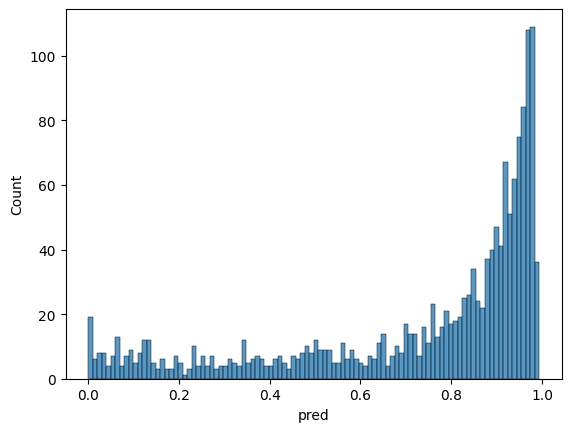

In [40]:
pred = models[key].predict_proba(X_test)[:, 1]
RESULTS_PRES = pd.DataFrame()
RESULTS_PRES['pred'] = pred
RESULTS_PRES['true'] = y_test
manual_cutpoint = 0.69
RESULTS_PRES['pred_val'] = (RESULTS_PRES['pred'] >= manual_cutpoint).astype('int')
sns.histplot(RESULTS_PRES[RESULTS_PRES.true==1], x='pred', bins=100)
print(classification_report(RESULTS_PRES['true'], RESULTS_PRES['pred_val'], target_names=model_labels))
RESULTS_PRES.set_index(X_test.index, inplace=True)

In [41]:
def obtaining_game_and_play_ids(gameplay_id):
    game, play, frame= gameplay_id.split('_')
    return game, play
    
def compute_features(df):
    df = df.copy()
    df['game_play'] = df.gameId.astype('str') + '_' + df.playId.astype('str')
    event_occurence = df.drop_duplicates(['gameId', 'playId','frameId'])[cols]
    event_occurence['game_play_frame_id'] = event_occurence.apply(lambda x: f'{x.gameId}_{x.playId}_{x.frameId}', axis=1)
    
    reduced_play_df = play_df[play_df.game_play.isin(df['game_play'])]

    reduced_play_df['team_deffinition'] = reduced_play_df.apply(lambda x: {x.possessionTeam: 1, x.defensiveTeam: -1}, axis=1)
    reduced_play_df['gameClock_time'] = reduced_play_df.gameClock.str.split(':').apply(lambda x: int(x[0])*60 + int(x[1]))
    reduced_play_df['preSnapScore_difference'] = reduced_play_df['preSnapHomeScore'] - reduced_play_df['preSnapVisitorScore']
    reduced_play_df['receiverAlignment_0'] = reduced_play_df.receiverAlignment.fillna('0x0').str.split('x').apply(lambda x: x[0])
    reduced_play_df['receiverAlignment_1'] = reduced_play_df.receiverAlignment.fillna('0x0').str.split('x').apply(lambda x: x[1])

    reduced_play_columns = [
        'quarter',
        'down',
        'yardsToGo',
        'yardlineNumber',
        'absoluteYardlineNumber',
        'preSnapHomeTeamWinProbability',
        'preSnapVisitorTeamWinProbability',
        'gameClock_time',
        'receiverAlignment_0',
        'receiverAlignment_1',
        'game_play',
        'team_deffinition',
    ]
    reduced_play_df = reduced_play_df[reduced_play_columns]


    new_player_info_df = df.merge(players_df, on='nflId', how='left')[
        ['nflId','x', 'y','club', 's', 'a', 'dir','event', 'weight', 'position', 'dis', 'o', 'game_play_frame_id', 'game_play']
    ]
    new_player_info_df["encoded_position"] = lb_player_position.transform(new_player_info_df.position)
    new_player_info_df.drop(columns=['position'], inplace=True)
    new_player_info_df.loc[new_player_info_df.fillna(0).dir==90, 'dir'] = 91
    new_player_info_df.loc[new_player_info_df.fillna(0).dir==270, 'dir'] = 269
    new_player_info_df = new_player_info_df.merge(reduced_play_df[['game_play', 'team_deffinition']], on='game_play', how='left')
    play_df['game_play'] = play_df.gameId.astype('str') + '_' + play_df.playId.astype('str')

    new_player_info_df['team_deffinition'] = new_player_info_df.apply(
        lambda row: row.team_deffinition.get(row.club), axis=1
    )
    new_player_info_df.loc[new_player_info_df.club=='football', 'weight'] =  1.11

    new_player_info_df['current_position_influence'] = new_player_info_df.apply(influence_function_actual_pos, axis=1)
    new_player_info_df['action'] = new_player_info_df.weight*new_player_info_df.s*new_player_info_df.dis
    new_player_info_df['ke'] = 1/2*new_player_info_df.weight*new_player_info_df.s**2
    new_player_info_df['p'] = new_player_info_df.weight*new_player_info_df.s
    new_player_info_df['px'] = new_player_info_df.weight*new_player_info_df.s*np.cos(np.deg2rad(new_player_info_df.dir))
    new_player_info_df['py'] = new_player_info_df.weight*new_player_info_df.s*np.sin(np.deg2rad(new_player_info_df.dir))
    new_player_info_df['fx'] = new_player_info_df.weight*new_player_info_df.a*np.cos(np.deg2rad(new_player_info_df.dir))
    new_player_info_df['fy'] = new_player_info_df.weight*new_player_info_df.a*np.sin(np.deg2rad(new_player_info_df.dir))
    new_player_info_df['f'] = new_player_info_df.weight*new_player_info_df.a
    new_player_info_df['work'] = new_player_info_df.f*new_player_info_df.dis

    # This can be done at a general scope
    general_reduced_tracking_w_player_info_df = new_player_info_df.groupby('game_play_frame_id').agg(
        {'dis':'sum', 'ke': 'sum', 'f': 'sum', 'fx': 'sum', 'fy': 'sum', 'p':'sum', 'px': 'sum', 'py':'sum','work': 'sum', 'action':'sum', 'x': 'mean', 'y':'mean'}
    )
    team_reduced_tracking_w_player_info_df = new_player_info_df[new_player_info_df.club != 'football'].groupby(['game_play_frame_id', 'club']).agg(
        {'dis':'sum', 'ke': 'sum', 'f': 'sum', 'fx': 'sum', 'fy': 'sum', 'p':'sum', 'px': 'sum', 'py':'sum', 'work': 'sum', 'action':'sum', 'x': 'mean', 'y':'mean', 'game_play': 'first', 'team_deffinition': 'first', 'current_position_influence': 'mean'}
    ).reset_index()

    # Or as a team scope
    team_reduced_tracking_w_player_info_df_possesion = team_reduced_tracking_w_player_info_df[
        team_reduced_tracking_w_player_info_df.team_deffinition == 1
    ].drop(['club', 'game_play', 'team_deffinition'], axis=1).set_index('game_play_frame_id')
    team_reduced_tracking_w_player_info_df_defensive = team_reduced_tracking_w_player_info_df[
        team_reduced_tracking_w_player_info_df.team_deffinition == -1
    ].drop(['club', 'game_play', 'team_deffinition'], axis=1).set_index('game_play_frame_id')
    
    team_reduced_tracking_w_player_info_df_difference = (
        team_reduced_tracking_w_player_info_df_possesion -
        team_reduced_tracking_w_player_info_df_defensive
    )
    
    team_reduced_tracking_w_player_info_df_difference = team_reduced_tracking_w_player_info_df_difference.rename(
        columns={col: f'{col}__difference' for col in team_reduced_tracking_w_player_info_df_difference.columns}
    )
    general_reduced_tracking_w_player_info_df = general_reduced_tracking_w_player_info_df.rename(
        columns={col: f'{col}__general' for col in general_reduced_tracking_w_player_info_df.columns}
    )

    most_influence_defensive = new_player_info_df[new_player_info_df.team_deffinition==-1].sort_values('current_position_influence', ascending=True).groupby('game_play_frame_id').agg(
        {'encoded_position': 'first', 'current_position_influence': 'first'}
    ).rename(columns={'encoded_position':'most_influence_encoded_position_defensive', 'current_position_influence':'most_influence_defensive',})

    most_influence_possesion = new_player_info_df[new_player_info_df.team_deffinition==1].sort_values('current_position_influence', ascending=False).groupby('game_play_frame_id').agg(
        {'encoded_position': 'first', 'current_position_influence': 'first'}
    ).rename(columns={'encoded_position':'most_influence_encoded_position_possesion', 'current_position_influence':'most_influence_possesion',})

    general_vs_team_distance_metrics = new_player_info_df.groupby('game_play_frame_id').apply(get_metrics_distance_between_team_players)
    general_vs_team_distance_metrics = pd.json_normalize(general_vs_team_distance_metrics).set_index(general_vs_team_distance_metrics.index)

    # Metrics of the ball position relative to the teams can also be computed:
    football_info_df = new_player_info_df[new_player_info_df.club == 'football'].set_index('game_play_frame_id')
    football_info_df.drop(['nflId', 'dir', 'event', 'weight', 'encoded_position', 'o', 'action', 'ke', 'fx', 'fy', 'f', 'px', 'py', 'work', 'club'], axis=1, inplace=True)
    football_info_df['distance_general'] = (general_reduced_tracking_w_player_info_df.x__general - football_info_df.x)**2 + (general_reduced_tracking_w_player_info_df.y__general - football_info_df.y)**2
    football_info_df['distance_possesion_team'] = (football_info_df.x-team_reduced_tracking_w_player_info_df_possesion.x)**2 + (football_info_df.y-team_reduced_tracking_w_player_info_df_possesion.y)**2
    football_info_df['distance_defensive_team'] = (football_info_df.x-team_reduced_tracking_w_player_info_df_defensive.x)**2 + (football_info_df.y-team_reduced_tracking_w_player_info_df_defensive.y)**2
    
    all_players_reduced_tracking_positions = new_player_info_df[new_player_info_df.club != 'football'].set_index('game_play_frame_id')[['x', 'y', 'encoded_position', 'game_play', 'club']]
    all_players_reduced_tracking_positions['distance_to_football'] = list((football_info_df.x-all_players_reduced_tracking_positions.x)**2 + (football_info_df.y-all_players_reduced_tracking_positions.y)**2)
    all_players_reduced_tracking_positions.reset_index(inplace=True)
    all_players_reduced_tracking_positions = all_players_reduced_tracking_positions.merge(reduced_play_df[['game_play', 'team_deffinition']], on='game_play', how='left')
    all_players_reduced_tracking_positions['team_deffinition'] = all_players_reduced_tracking_positions.apply(
        lambda row: row.team_deffinition[row.club], axis=1
    )
    
    min_distances_to_ball = all_players_reduced_tracking_positions.sort_values(
        ['game_play_frame_id', 'distance_to_football', 'team_deffinition']
    ).drop_duplicates(
        ['game_play_frame_id', 'team_deffinition'], keep='first'
    )
    
    min_distances_to_ball_defensive = min_distances_to_ball[min_distances_to_ball.team_deffinition==-1].set_index('game_play_frame_id')[['encoded_position', 'distance_to_football']]
    min_distances_to_ball_possesion = min_distances_to_ball[min_distances_to_ball.team_deffinition==1].set_index('game_play_frame_id')[['encoded_position', 'distance_to_football']]
    
    min_distances_to_ball_defensive.rename(columns={col: f'min_{col}_defensive' for col in min_distances_to_ball_defensive.columns}, inplace=True)
    min_distances_to_ball_possesion.rename(columns={col: f'min_{col}_possesion' for col in min_distances_to_ball_possesion.columns}, inplace=True)
    football_info_df.rename(columns={col:f'football_{col}' for col in football_info_df.columns}, inplace=True)
    football_info_df.drop(['football_team_deffinition'], axis=1, inplace=True)

    graphs = new_player_info_df.groupby('game_play_frame_id').apply(get_graph_with_nodes_attrs, no_negatives=True)

    # adjacent_embeddings = graphs.apply(get_adjacent_embedding)

    # adjacent_embeddings_df = pd.DataFrame(
    #     np.concatenate(adjacent_embeddings.to_numpy()).reshape(adjacent_embeddings.shape[0], len(adjacent_embeddings[0])),
    #     index=adjacent_embeddings.index,
    #     columns=[f'adjacent_{i}' for i in range(len(adjacent_embeddings[0]))],
    # )
    # del adjacent_embeddings

    feather_embeddings = graphs.apply(get_feathergraph_embedding)

    feather_embeddings_df = pd.DataFrame(
        np.concatenate(feather_embeddings.to_numpy()).reshape(feather_embeddings.shape[0], len(feather_embeddings[0])),
        index=feather_embeddings.index,
        columns=[f'feather_embeddings_{i}' for i in range(len(feather_embeddings[0]))],
    )
    del feather_embeddings

    # fgsd_embeddings = graphs.apply(get_fgsd_embedding)
    
    # fgsd_embeddings_df = pd.DataFrame(
    #     np.concatenate(fgsd_embeddings.to_numpy()).reshape(fgsd_embeddings.shape[0], len(fgsd_embeddings[0])),
    #     index=fgsd_embeddings.index,
    #     columns=[f'fgsd_embeddings_{i}' for i in range(len(fgsd_embeddings[0]))],
    # )
    # del fgsd_embeddings

    current_event_stuff = event_occurence.set_index('game_play_frame_id')[['frameType', 'playDirection']]
    current_event_stuff['frameType'] = current_event_stuff.frameType.map({'BEFORE_SNAP': 0, 'AFTER_SNAP': 1, 'SNAP':0.5})
    current_event_stuff['playDirection'] = current_event_stuff.playDirection.map({'right': 0, 'left': 1})

    result_df_list = [
        current_event_stuff, # Contains response var
        team_reduced_tracking_w_player_info_df_difference,
        general_reduced_tracking_w_player_info_df,
        min_distances_to_ball_defensive,
        min_distances_to_ball_possesion,
        football_info_df,
        general_vs_team_distance_metrics,
        most_influence_defensive, 
        most_influence_possesion,
        #fgsd_embeddings_df,
        #adjacent_embeddings_df,
        feather_embeddings_df,
    ]
    all_features = reduce(lambda  left, right: pd.merge(left, right, left_index=True, right_index=True, how='left'), result_df_list)
    all_features_pca = get_pca_feather_embeddings(pca=pca_model, x=all_features.select_dtypes('number'))

    return all_features_pca, graphs

In [42]:
sample_result = RESULTS_PRES[RESULTS_PRES.pred >= manual_cutpoint].sample(1)

sample_game, sample_play = obtaining_game_and_play_ids(sample_result.index[0])
sample_tracking = tracking_df[
    ((tracking_df.gameId == int(sample_game)) & 
    (tracking_df.playId == int(sample_play)))
]

sample_tracking_features, sample_tracking_graphs  = compute_features(sample_tracking)
sample_tracking_features['model_prediction'] = models['XGBClassifier'].predict_proba(sample_tracking_features)[:, 1]
sample_tracking_features['graphs'] = sample_tracking_graphs
frame_sample_tracking = sample_tracking.set_index("game_play_frame_id").copy().drop_duplicates(['gameId', 'playId','frameId'])[cols]
frame_sample_tracking = frame_sample_tracking.merge(sample_tracking_features[['model_prediction', 'graphs']], left_index=True, right_index=True)
frame_sample_tracking.time = pd.to_datetime(frame_sample_tracking.time, format='ISO8601')

In [43]:
# frame_sample_tracking['manual_cutpoint'] = manual_cutpoint
# frame_sample_tracking.time = pd.to_datetime(frame_sample_tracking.time, format='ISO8601')

# counter=0
# for idx, row in frame_sample_tracking.iterrows():
#     fig, ax = plot_field()
#     draw_graph2(row.graphs, ax=ax[0])
#     # This is just for figure 1: probability plot. 
#     increasing_df = frame_sample_tracking.loc[:idx]
#     # color definition: pre and post snap:
#     color = 'darkgreen'
#     if increasing_df.frameType.iloc[-1] == 'BEFORE_SNAP':
#         color='crimson'
#     # background color definition: depending in prediction
#     background_color = 'white'
#     if increasing_df.model_prediction.iloc[-1] >= manual_cutpoint:
#         background_color='gold'
    
        
#     try:
#         for idx2, values in increasing_df.dropna().iterrows():
#             ax[1].vlines(values.time, 0, 1, color='k')
#             ax[1].text(values.time, 1+0.05, values.event, horizontalalignment='center', verticalalignment='center', size=7)
#     except:
#         pass
#     ax[1].plot(increasing_df.time, increasing_df.model_prediction, color=color)
#     ax[1].plot(increasing_df.time, increasing_df.manual_cutpoint, color='k', alpha=0.5, linestyle='--')
#     ax[1].fill_between(increasing_df.time, 0, increasing_df.model_prediction, color=background_color, alpha=0.1)
#     ax[1].set_ylim(0, 1.2)
#     ax[1].set_title('Model Prediction over time')
#     ax[1].set_xlabel('Time')
#     ax[1].set_ylabel('Score of "pass_foward" at the next second.')
#     ax[1].grid(linestyle='--')

#     # Model saving and closing. 
#     plt.savefig(f'../figures/experiments_d10/test_{str(counter).zfill(3)}.png')
#     plt.close(fig)
#     counter+=1
#     #print(counter)
#     #if counter == 3:
#     #    break

In [44]:
# def create_gif(image_paths, output_gif_path, duration=50):
#   images = [Image.open(image_path) for image_path in image_paths]
#   images[0].save(
#     output_gif_path,
#     save_all=True,
#     append_images=images[1:],
#     #duration=duration,
#     fps=10,
#     loop=0 # 0 means infinite loop
#   )

# image_paths = [os.path.join('../figures/experiments_d10', p) for p in sorted(os.listdir('../figures/experiments_d10'))]
# output_gif_path = "../outputs/output10.gif"
# create_gif(image_paths, output_gif_path)

In [45]:
explainer = shap.TreeExplainer(models['XGBClassifier'])
shap_values = explainer.shap_values(sample_tracking_features.drop(['model_prediction', 'graphs'], axis=1))

In [46]:
c = sample_tracking_features.columns[:-2]
args_max = pd.DataFrame(shap_values, columns=c).abs().T.apply(lambda x: list(reversed(np.argsort(x))), axis=0).T
pd.set_option('display.max_rows', 175)

args_max = pd.DataFrame(shap_values, columns=c).abs().T.apply(lambda x: list(reversed(np.argsort(x))), axis=0).reset_index(drop=True)
top3_features = args_max.iloc[:3].T
top3_features = top3_features.apply(lambda x: c[x]).rename(columns={col: f'important_feature{col}' for col in top3_features.columns}).set_index(frame_sample_tracking.index)

top_3_features_values = top3_features.apply(
    lambda row: pd.Series(
        sample_tracking_features.loc[row.name][
        [row.important_feature0, row.important_feature1, row.important_feature2]
        ].values, index=['important_feature0', 'important_feature1','important_feature2']
    ), axis=1
)
top3_features_w_vals = top3_features  +"= " + top_3_features_values.round(3).astype('string')

In [47]:
pd.set_option('display.max_rows', 200)
frame_sample_tracking.merge(top3_features_w_vals, right_index=True, left_index=True)

,gameId,playId,frameId,frameType,time,playDirection,event,model_prediction,graphs,important_feature0,important_feature1,important_feature2
game_play_frame_id,,,,,,,,,,,,
2022092500_3571_1,2022092500,3571,1,BEFORE_SNAP,2022-09-25 19:40:17.700,left,huddle_break_offense,0.000027,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",frameType= 0.0,football_distance_defensive_team= 26.27,pca_feather_embedding_11= 0.395
2022092500_3571_2,2022092500,3571,2,BEFORE_SNAP,2022-09-25 19:40:17.800,left,NaN,0.000093,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",frameType= 0.0,football_distance_defensive_team= 26.379,football_s= 0.01
2022092500_3571_3,2022092500,3571,3,BEFORE_SNAP,2022-09-25 19:40:17.900,left,NaN,0.000287,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",frameType= 0.0,football_distance_defensive_team= 26.374,football_s= 0.01
2022092500_3571_4,2022092500,3571,4,BEFORE_SNAP,2022-09-25 19:40:18.000,left,NaN,0.000034,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",frameType= 0.0,football_distance_defensive_team= 26.352,football_s= 0.0
2022092500_3571_5,2022092500,3571,5,BEFORE_SNAP,2022-09-25 19:40:18.100,left,NaN,0.000216,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",frameType= 0.0,football_distance_defensive_team= 26.312,f__general= 2725.931
...,...,...,...,...,...,...,...,...,...,...,...,...
2022092500_3571_210,2022092500,3571,210,AFTER_SNAP,2022-09-25 19:40:38.600,left,pass_outcome_incomplete,0.007279,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",football_y= 63.11,football_distance_defensive_team= 740.01,football_distance_possesion_team= 1169.869
2022092500_3571_211,2022092500,3571,211,AFTER_SNAP,2022-09-25 19:40:38.700,left,NaN,0.006948,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",football_distance_defensive_team= 747.748,football_y= 63.23,football_distance_possesion_team= 1181.532
2022092500_3571_212,2022092500,3571,212,AFTER_SNAP,2022-09-25 19:40:38.800,left,NaN,0.014759,"(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",football_y= 63.35,football_distance_defensive_team= 756.83,football_distance_possesion_team= 1194.314


## Pass outcome caught

In [48]:
d1_step2 = {f'{col}':f'{col}' for col in y.unique() if "pass_outcome_caught" in col} 
d2_step2 = {f'{col}':f'Other' for col in y.unique() if "pass_outcome_caught" not in col}
d1_step2.update(d2_step2)
y_pass_outcome = y.map(d1_step2)

In [49]:
y_pass_outcome.value_counts()

future_event
Other                  104232
pass_outcome_caught      4879
Name: count, dtype: int64

In [50]:
xnew = get_pca_feather_embeddings(pca=pca_model, x=X.copy())
xnew["pass_prediction"] = models['XGBClassifier'].predict_proba(xnew)[:, 1]

In [51]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    xnew, y_pass_outcome, test_size=0.2, random_state=RANDOM_SEED, stratify=y_pass_outcome
)

lb2 = LabelEncoder()
lb2.fit(y_train2)
y_train2 = lb2.transform(y_train2)
y_test2 = lb2.transform(y_test2)

In [87]:
with open('../models/models1/lb2.pkl', 'wb') as f:
    pickle.dump(lb2, f)

In [52]:
model_labels_dict2 = {val: lb2.inverse_transform([val])[0] for val in pd.Series(y_test2).unique()}
model_labels2 = [model_labels_dict2[element] for element in sorted(model_labels_dict2)]

In [53]:
scale_pos_weight2 = (y_train2==0).sum()/(y_train2==1).sum()

In [54]:
models2 = {}
#models['LogisticRegression'] = LogisticRegression()
#models['SVC'] = SVC()
#models['RandomForestClassifier'] = RandomForestClassifier()
models2['XGBClassifier'] = XGBClassifier(scale_pos_weight=scale_pos_weight2)

#models['LogisticRegression'].fit(X_train, y_train)
#models['SVC'].fit(X_train, y_train)
#models['RandomForestClassifier'].fit(X_train, y_train)
models2['XGBClassifier'].fit(X_train2, y_train2)

prediction2 = {}
for key in models2.keys():
  prediction2[key] = models2[key].predict(X_test2)

In [88]:
with open('../models/models1/model2.pkl', 'wb') as f:
    pickle.dump(models2['XGBClassifier'], f)

In [55]:
# All information
for key in models.keys():
  print(f'Model: {key}')
  print(classification_report(y_test2, prediction2[key], target_names=model_labels2))

Model: XGBClassifier
                     precision    recall  f1-score   support

              Other       0.98      0.92      0.95     20847
pass_outcome_caught       0.27      0.67      0.39       976

           accuracy                           0.91     21823
          macro avg       0.63      0.79      0.67     21823
       weighted avg       0.95      0.91      0.92     21823



In [56]:
d1_step3 = {f'{col}':f'{col}' for col in y.unique() if "pass_outcome_incomplete" in col} 
d2_step3 = {f'{col}':f'Other' for col in y.unique() if "pass_outcome_incomplete" not in col}
d1_step3.update(d2_step3)
y_pass_outcome_incomplete = y.map(d1_step3)

In [57]:
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    xnew, y_pass_outcome_incomplete, test_size=0.2, random_state=RANDOM_SEED, stratify=y_pass_outcome_incomplete
)

lb3 = LabelEncoder()
lb3.fit(y_train3)
y_train3 = lb3.transform(y_train3)
y_test3 = lb3.transform(y_test3)

model_labels_dict3 = {val: lb3.inverse_transform([val])[0] for val in pd.Series(y_test3).unique()}
model_labels3 = [model_labels_dict3[element] for element in sorted(model_labels_dict3)]

In [89]:
with open('../models/models1/lb3.pkl', 'wb') as f:
    pickle.dump(lb3, f)

In [58]:
scale_pos_weight3 = (y_train3==0).sum()/(y_train3==1).sum()

In [59]:
models3 = {}
#models['LogisticRegression'] = LogisticRegression()
#models['SVC'] = SVC()
#models['RandomForestClassifier'] = RandomForestClassifier()
models3['XGBClassifier'] = XGBClassifier(scale_pos_weight=scale_pos_weight3)

#models['LogisticRegression'].fit(X_train, y_train)
#models['SVC'].fit(X_train, y_train)
#models['RandomForestClassifier'].fit(X_train, y_train)
models3['XGBClassifier'].fit(X_train3, y_train3)

prediction3 = {}
for key in models2.keys():
  prediction3[key] = models3[key].predict(X_test3)

In [90]:
with open('../models/models1/model3.pkl', 'wb') as f:
    pickle.dump(models3['XGBClassifier'], f)

In [60]:
# All information
for key in models.keys():
  print(f'Model: {key}')
  print(classification_report(y_test3, prediction3[key], target_names=model_labels3))

Model: XGBClassifier
                         precision    recall  f1-score   support

                  Other       0.99      0.96      0.97     21310
pass_outcome_incomplete       0.22      0.46      0.30       513

               accuracy                           0.95     21823
              macro avg       0.60      0.71      0.64     21823
           weighted avg       0.97      0.95      0.96     21823



### Pass arrived

In [61]:
d1_step0 = {f'{col}':f'{col}' for col in y.unique() if "pass_arrived" in col} 
d2_step0 = {f'{col}':f'Other' for col in y.unique() if "pass_arrived" not in col}
d1_step0.update(d2_step0)
y_pass_arrived = y.map(d1_step0)

In [62]:
X_train0, X_test0, y_train0, y_test0 = train_test_split(
    xnew, y_pass_arrived, test_size=0.2, random_state=RANDOM_SEED, stratify=y_pass_arrived
)

lb0 = LabelEncoder()
lb0.fit(y_train0)
y_train0 = lb0.transform(y_train0)
y_test0 = lb0.transform(y_test0)

model_labels_dict0 = {val: lb0.inverse_transform([val])[0] for val in pd.Series(y_test0).unique()}
model_labels0 = [model_labels_dict0[element] for element in sorted(model_labels_dict0)]

scale_pos_weight0 = (y_train0==0).sum()/(y_train0==1).sum()

In [92]:
with open('../models/models1/lb0.pkl', 'wb') as f:
    pickle.dump(lb0, f)

In [63]:
models0 = {}
#models['LogisticRegression'] = LogisticRegression()
#models['SVC'] = SVC()
#models['RandomForestClassifier'] = RandomForestClassifier()
models0['XGBClassifier'] = XGBClassifier(scale_pos_weight=scale_pos_weight0)

#models['LogisticRegression'].fit(X_train, y_train)
#models['SVC'].fit(X_train, y_train)
#models['RandomForestClassifier'].fit(X_train, y_train)
models0['XGBClassifier'].fit(X_train0, y_train0)

prediction0 = {}
for key in models2.keys():
  prediction0[key] = models0[key].predict(X_test0)

In [91]:
with open('../models/models1/model0.pkl', 'wb') as f:
    pickle.dump(models0['XGBClassifier'], f)

In [64]:
# All information
for key in models.keys():
  print(f'Model: {key}')
  print(classification_report(y_test0, prediction0[key], target_names=model_labels0))

Model: XGBClassifier
              precision    recall  f1-score   support

       Other       0.98      0.91      0.95     20582
pass_arrived       0.33      0.73      0.46      1241

    accuracy                           0.90     21823
   macro avg       0.66      0.82      0.70     21823
weighted avg       0.95      0.90      0.92     21823



In [93]:
X_train4, X_test4, y_train4, y_test4 = train_test_split(
    xnew, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y_pass_arrived
)

lb4 = LabelEncoder()
lb4.fit(y_train4)
y_train4 = lb4.transform(y_train4)
y_test4 = lb4.transform(y_test4)

model_labels_dict4 = {val: lb4.inverse_transform([val])[0] for val in pd.Series(y_test4).unique()}
model_labels4 = [model_labels_dict4[element] for element in sorted(model_labels_dict4)]

#scale_pos_weight0 = (y_train0==0).sum()/(y_train0==1).sum()

In [95]:
models4 = {}
#models['LogisticRegression'] = LogisticRegression()
#models['SVC'] = SVC()
#models['RandomForestClassifier'] = RandomForestClassifier()
models4['XGBClassifier'] = XGBClassifier()

#models['LogisticRegression'].fit(X_train, y_train)
#models['SVC'].fit(X_train, y_train)
#models['RandomForestClassifier'].fit(X_train, y_train)
models4['XGBClassifier'].fit(X_train4, y_train4)

prediction4 = {}
for key in models2.keys():
  prediction4[key] = models4[key].predict(X_test4)

In [96]:
# All information
for key in models4.keys():
  print(f'Model: {key}')
  print(classification_report(y_test4, prediction4[key], target_names=model_labels4))

Model: XGBClassifier
                           precision    recall  f1-score   support

                     None       0.49      0.34      0.40      4373
    autoevent_passforward       0.00      0.00      0.00         5
autoevent_passinterrupted       0.00      0.00      0.00        34
                ball_snap       0.56      0.77      0.65      2904
             dropped_pass       0.00      0.00      0.00        56
            first_contact       0.52      0.61      0.56      1862
                   fumble       0.00      0.00      0.00        44
 fumble_defense_recovered       0.00      0.00      0.00        22
 fumble_offense_recovered       0.00      0.00      0.00        24
                  handoff       0.66      0.77      0.71      1014
     huddle_start_offense       0.00      0.00      0.00         2
                  lateral       0.00      0.00      0.00        12
                 line_set       0.66      0.81      0.73      2731
            man_in_motion       0.34    

In [70]:
sample_result = RESULTS_PRES[RESULTS_PRES.pred >= manual_cutpoint].sample(1)

In [71]:
sample_game, sample_play = obtaining_game_and_play_ids(sample_result.index[0])
sample_tracking = tracking_df[
    ((tracking_df.gameId == int(sample_game)) & 
    (tracking_df.playId == int(sample_play)))
]
sample_tracking_features, sample_tracking_graphs  = compute_features(sample_tracking)

In [72]:
sample_tracking_features['pass_prediction'] = models['XGBClassifier'].predict_proba(sample_tracking_features)[:, 1]
pass_outcome_caught = models2['XGBClassifier'].predict_proba(sample_tracking_features)[:, 1]
pass_outcome_incomplete = models3['XGBClassifier'].predict_proba(sample_tracking_features)[:, 1]
pass_arrived = models0['XGBClassifier'].predict_proba(sample_tracking_features)[:, 1]
sample_tracking_features['graphs'] = sample_tracking_graphs
frame_sample_tracking = sample_tracking.set_index("game_play_frame_id").copy().drop_duplicates(['gameId', 'playId','frameId'])[cols]
frame_sample_tracking['manual_cutpoint'] = manual_cutpoint
frame_sample_tracking = frame_sample_tracking.merge(sample_tracking_features[['pass_prediction', 'graphs']], left_index=True, right_index=True)
frame_sample_tracking.time = pd.to_datetime(frame_sample_tracking.time, format='ISO8601')
frame_sample_tracking['pass_outcome_caught_prediction'] = pass_outcome_caught
frame_sample_tracking['pass_outcome_caught_incomplete'] = pass_outcome_incomplete
frame_sample_tracking['pass_arrived'] = pass_arrived
frame_sample_tracking['pass_outcome_difference'] = (
    frame_sample_tracking['pass_outcome_caught_prediction'] - frame_sample_tracking['pass_outcome_caught_incomplete']
)
frame_sample_tracking['reframed_pass_outcome_difference'] = frame_sample_tracking.pass_outcome_difference[10:].to_list() + [0]*10
frame_sample_tracking.loc[frame_sample_tracking.pass_prediction<manual_cutpoint, 'reframed_pass_outcome_difference'] = 0

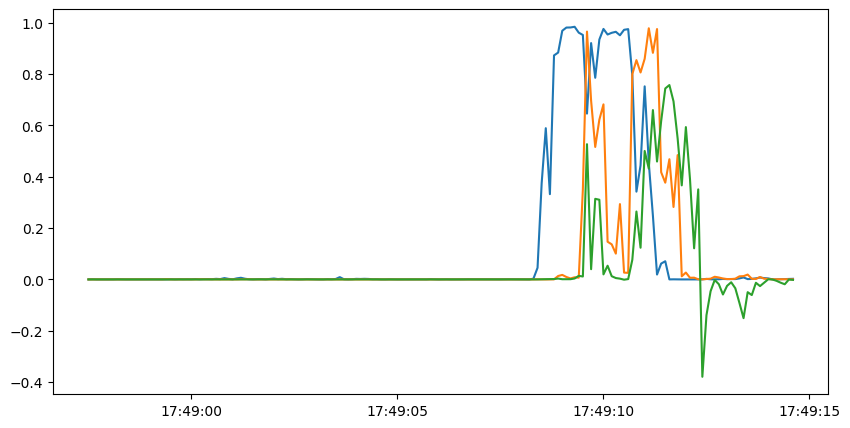

In [73]:
plt.figure(figsize=(10,5))
plt.plot(frame_sample_tracking.time, frame_sample_tracking.pass_prediction)
plt.plot(frame_sample_tracking.time, frame_sample_tracking.pass_arrived)
plt.plot(frame_sample_tracking.time, frame_sample_tracking.pass_outcome_difference)

In [74]:
def create_folder(filename, path="../figures/"):
    complete_path = os.path.join(path, filename)
    if os.path.exists(complete_path):
        return None
    os.mkdir(complete_path)
    return complete_path

#### PLOT
def save_figs(frame_sample_tracking, filename, show=False, save=False, stop_counter=None):
    complete_path = create_folder(filename=filename)
    if complete_path is None:
        return None
    counter=0
    for idx, row in frame_sample_tracking.iterrows():
        
        increasing_frame_sample_tracking = frame_sample_tracking.loc[:idx]
        fig, ax = plot_field(subplots=3, figsize=(15,15))
        
        draw_graph2(row.graphs, ax=ax[0])
    
        ax[1].plot(
            increasing_frame_sample_tracking.time, 
            increasing_frame_sample_tracking.pass_prediction,
            color='blue', 
            marker='o',
            markerfacecolor='k',
            markersize=3,
            label='pass_prediction',
        )
        ax[1].plot(
            increasing_frame_sample_tracking.time, 
            increasing_frame_sample_tracking.pass_arrived,
            color='purple', 
            marker='o',
            markerfacecolor='k',
            markersize=3,
            label='pass_arrived',
        )
        ax[1].plot(
            increasing_frame_sample_tracking.time, 
            increasing_frame_sample_tracking.manual_cutpoint, 
            color='gray', 
            linestyle='--', 
            label='pass prediction threshold')
        ax[2].plot(
            increasing_frame_sample_tracking.time,
            increasing_frame_sample_tracking.reframed_pass_outcome_difference,
            color='orange',
            marker='o', 
            markersize=3,
            markerfacecolor='k',
            alpha=0.9,     
            label='pass_outcome_prediction'
        )
        ax[2].plot(
            increasing_frame_sample_tracking.time, 
            [0]*increasing_frame_sample_tracking.shape[0], 
            color='gray', 
            linestyle='--',
            label='Decision line' 
        )
    
        increasing_frame_sample_tracking_events = increasing_frame_sample_tracking[
            increasing_frame_sample_tracking.event.notna()
        ]
    
        ax[1].vlines(
            increasing_frame_sample_tracking_events.time, 
            [0 - 0.0] * increasing_frame_sample_tracking_events.shape[0], 
            [1 - 0.05] * increasing_frame_sample_tracking_events.shape[0],
            color='k',
            alpha=0.8,
        )
    
        ax[2].vlines(
            increasing_frame_sample_tracking_events.time, 
            [-1+0.05] * increasing_frame_sample_tracking_events.shape[0], 
            [1-0.05] * increasing_frame_sample_tracking_events.shape[0],
            color='k',
            alpha=0.8
        )
        counter_text = 0
        for _, row_event in increasing_frame_sample_tracking_events.iterrows():
            counter_text +=1
            ax[1].text(row_event.time, counter_text%2 - (-1)**counter_text*0.05, row_event.event, size=5,  horizontalalignment='center', verticalalignment='center',)
            ax[2].text(row_event.time, (-1)**counter_text, row_event.event, size=5,  horizontalalignment='center', verticalalignment='center',)
        ax[1].set_ylim(-0.15, 1.1)
    
        plt.suptitle('Models development over time. ')
        ax[1].set_title('Overall teams mechanical behavior')
    
        ax[1].set_title('Pass Forward computation predicted by the overall teams mechanical behavior over time.')
        ax[1].set_xlabel('Time')
        ax[1].set_ylabel('Score of "pass_forward" at the next second.')
        ax[1].grid(linestyle='--')
        
        ax[2].set_title('Pass Ouctome prediction.')
        ax[2].set_xlabel('Time')
        ax[2].set_ylabel('Score of "pass_forward outcome" at the next second \n adjusted to current model performance.')
        ax[2].grid(linestyle='--')
    
        ax[1].legend()
        ax[2].legend()
        if show:
            plt.show()
        if save:
            plt.savefig(f'{complete_path}/test_{str(counter).zfill(3)}.png')
        plt.close(fig)
        counter += 1
        if stop_counter:
            if counter==stop_counter:
                break
        #if counter == 3:
        #    break

def create_gif(image_paths, output_gif_path, duration=50):
  images = [Image.open(image_path) for image_path in image_paths]
  images[0].save(
    output_gif_path,
    save_all=True,
    append_images=images[1:],
    #duration=duration,
    fps=10,
    loop=1 # 0 means infinite loop
  )

def save_gif(filename):
    image_paths = [os.path.join(f'../figures/{filename}', p) for p in sorted(os.listdir(f'../figures/{filename}'))]
    filename_split = filename.split('_')[-1]
    output_gif_path = f"../outputs/output_{filename_split}.gif"
    create_gif(image_paths, output_gif_path)


In [75]:
EXPERIMENTS_NAME = 'experiments_d1'
save_figs(frame_sample_tracking=frame_sample_tracking, filename=EXPERIMENTS_NAME, show=False, save=True, stop_counter=None)
save_gif(filename=EXPERIMENTS_NAME)

# EXPERIMENTS

In [ ]:
#influence_function(analysis_unit)(0,0)

In [ ]:
def get_rotation_matrix(direction):
    theta = np.radians(direction)
    rotation_matrix = np.array(
        [[np.cos(theta), -np.sin(theta)],
         [np.sin(theta), np.cos(theta)]]
    )
    return rotation_matrix

def get_scaling_matrix(speed):
    max_speed = 13  #Max speed proposed in paper over the tracking data
    influence_radius = 4  # Influence in yards of the player.
    s_rat = (speed/max_speed)**2
    sx = (influence_radius + influence_radius * s_rat) / 2
    sy = (influence_radius - influence_radius * s_rat) / 2
    scaling_matrix = np.array(
        [[sx, 0],
         [0, sy]]
    )
    return scaling_matrix

def get_cov_matrix(direction, speed):
    rotation_matrix = get_rotation_matrix(direction)
    scaling_matrix = get_scaling_matrix(speed)
    inverse_rotation_matrix = np.linalg.inv(rotation_matrix)
    return rotation_matrix @ scaling_matrix @ scaling_matrix @ inverse_rotation_matrix

def influence(player):
  mean = np.array([
      player.x + 1/2*player.s*np.cos(np.deg2rad(player.dir)),
      player.y + 1/2*player.s*np.sin(np.deg2rad(player.dir))
  ])
  cov_matrix = get_cov_matrix(player.dir, player.s)
  cov_matrix_det = np.linalg.det(cov_matrix)
  cov_matrix_inv = np.linalg.inv(cov_matrix)
  func = lambda positions: 1/np.sqrt(2*np.pi*cov_matrix_det)*np.exp((-1/2)*(positions-mean).T @ cov_matrix_inv @ (positions-mean))
  return func

In [ ]:
def get_team_influences_func(analysis_unit):
  team_influences = {}
  for i in range(analysis_unit.shape[0]-1):
    team_influences[f'player{i}'] = influence(analysis_unit.iloc[i])
  return team_influences


def get_team_influence_mesh(analysis_unit):
  team_influences = get_team_influences_func(analysis_unit)
  mg = np.array(np.meshgrid(np.linspace(0, 120, 50), np.linspace(0, 53.3333, 50)))
  xx, yy = mg
  z = np.zeros_like(xx, dtype=np.float32)
  for i in range(xx.shape[0]):
      for j in range(xx.shape[1]):
        for player, func in team_influences.items():
          z[i, j] = z[i, j] + func(np.array([xx[i, j], yy[i, j]]))
  return z

In [ ]:
analysis_unit.dir

In [ ]:

def get_velocity_matrix(analysis_unit, not_ball=True):
  analysis_unit = analysis_unit.copy()
  if not_ball:
    analysis_unit = get_analysis_unit_without_ball(analysis_unit)
  analysis_unit['vx'] = analysis_unit.s*np.cos(np.deg2rad(analysis_unit.dir))
  analysis_unit['vy'] = analysis_unit.s*np.sin(np.deg2rad(analysis_unit.dir))
  # Get distance matrix
  velocity_matrix = ss.distance_matrix(
      analysis_unit[['vx', 'vy']],
      analysis_unit[['vx', 'vy']])
  velocity_matrix = np.nan_to_num(velocity_matrix, nan=0)
  return velocity_matrix

def get_acceleration_matrix(analysis_unit, not_ball=True):
  analysis_unit = analysis_unit.copy()
  if not_ball:
    analysis_unit = get_analysis_unit_without_ball(analysis_unit)

  analysis_unit['ax'] = analysis_unit.a*np.cos(np.deg2rad(analysis_unit.dir))
  analysis_unit['ay'] = analysis_unit.a*np.sin(np.deg2rad(analysis_unit.dir))
  # Get distance matrix
  acceleration_matrix = ss.distance_matrix(
      analysis_unit[['ax', 'ay']],
      analysis_unit[['ax', 'ay']])
  acceleration_matrix = np.nan_to_num(acceleration_matrix, nan=0)

  return acceleration_matrix

def get_analysis_unit_without_ball(analysis_unit):
  analysis_unit_without_ball = analysis_unit[analysis_unit.club!='football']
  return analysis_unit_without_ball

def get_look_matrix(analysis_unit, not_ball=True):
  analysis_unit = analysis_unit.copy()
  if not_ball:
    analysis_unit = get_analysis_unit_without_ball(analysis_unit)
  # Get the analysis unit without the ball.

  # Get the angle matrix, depending in positions.
  angles_according_to_position = angle_matrix(
      analysis_unit[['x', 'y']],
      analysis_unit[['x', 'y']]
      )
  # Compare if positions are aligned to orientation or direction.
  angles_according_to_position_o = angles_according_to_position - np.asarray(analysis_unit.o)
  angles_according_to_position_dir = angles_according_to_position - np.asarray(analysis_unit.dir)
  # Normalize the direction with cosine
  # (if aligned then 1, if not then 0, and any values between that, also negative alignment is possible).
  look_o = np.cos(np.deg2rad(angles_according_to_position_o)) # Relevance depending in direction
  look_dir = np.cos(np.deg2rad(angles_according_to_position_dir))
  # Sum the contribution of both alingments, at 50%50.
  look = (look_o + look_dir)/2
  look = np.nan_to_num(look, nan=0)
  return look

def get_inverse_distance_matrix(analysis_unit, power=1, not_ball=True):
  analysis_unit = analysis_unit.copy()
  if not_ball:
    analysis_unit = get_analysis_unit_without_ball(analysis_unit)
  # Get distance matrix
  unit_distance_matrix = ss.distance_matrix(
      analysis_unit[['x', 'y']],
      analysis_unit[['x', 'y']])
  # Divide 1 over the values by a power
  inverse_distance_matrix = 1/unit_distance_matrix**(power)
  # Replace infinite with 0
  inverse_distance_matrix[inverse_distance_matrix==np.inf] = 0
  inverse_distance_matrix = np.nan_to_num(inverse_distance_matrix, nan=0)
  return inverse_distance_matrix

def get_mechanical_element_matrix_weighted_by_look(analysis_unit):
  velocity_matrix = get_velocity_matrix(analysis_unit)
  acceleration_matrix = get_acceleration_matrix(analysis_unit)
  inverse_distance_matrix = get_inverse_distance_matrix(analysis_unit)
  look = get_look_matrix(analysis_unit)

  velocity_matrix_weighted = velocity_matrix * look
  acceleration_matrix_weighted = acceleration_matrix * look
  inverse_distance_matrix_weighted = inverse_distance_matrix * look
  mechanical_element_matrix = (
      inverse_distance_matrix_weighted +
      1/10*velocity_matrix_weighted +
      1/100*acceleration_matrix_weighted
  )
  return mechanical_element_matrix

def get_inverse_distance_matrix_weighted_by_look(analysis_unit, not_ball=False):
  inverse_distance_matrix = get_inverse_distance_matrix(analysis_unit, not_ball=not_ball, power=1)
  look = get_look_matrix(analysis_unit, not_ball=not_ball)
  inverse_distance_matrix_weighted = inverse_distance_matrix*look
  return inverse_distance_matrix_weighted

def get_team_positions(analysis_unit):
  analysis_unit_without_ball = get_analysis_unit_without_ball(analysis_unit)
  pos = analysis_unit_without_ball[['x', 'y']].reset_index(drop=True)
  pos['xy'] = pos.apply(lambda x: np.array([x.x, x.y]), axis=1)
  pos = pos['xy'].to_dict()
  return pos

def get_team_graph(analysis_unit, not_ball=False):
  #matrix = get_mechanical_element_matrix_weighted_by_look(analysis_unit)
  matrix = get_inverse_distance_matrix_weighted_by_look(analysis_unit, not_ball=not_ball)
  G = nx.from_numpy_array(matrix)
  return G

def get_team_characteristics(analysis_unit):
  analysis_unit_without_ball = get_analysis_unit_without_ball(analysis_unit)
  analysis_unit_without_ball = analysis_unit_without_ball.reset_index(drop=True)
  desired_cols = ['displayName', 'jerseyNumber', 'club']
  characteristics_dict = {}
  for col in desired_cols:
    characteristics_dict[col] = analysis_unit_without_ball[col].to_dict()
  return characteristics_dict

def set_team_characteristics(analysis_unit, G):
  characteristics_dict = get_team_characteristics(analysis_unit)
  for col, char in characteristics_dict.items():
    nx.set_node_attributes(G, char, col)
  return G

In [ ]:
team_characteristics = get_team_characteristics(analysis_unit)
team_G = get_team_graph(analysis_unit)
team_G = set_team_characteristics(analysis_unit, team_G)
pos = get_team_positions(analysis_unit)

In [ ]:
def draw_graph2(G, pos, ax=None):
  colors=['tab:blue', 'tab:orange']
  color_dict = {}
  node_colors = []
  i=0
  for node, attr in team_G.nodes(data=True):
    club = attr['club']
    if club not in color_dict:
      color_dict[club] = colors[i]
      i+=1
    node_colors.append(color_dict[club])

  edges = team_G.edges()
  weights = [team_G[u][v]['weight'] for u,v in edges]
  ec = nx.draw_networkx_edges(team_G, pos, ax=ax, width=weights, alpha=0.5)
  nc = nx.draw_networkx_nodes(team_G, pos, ax=ax,node_color=node_colors, node_size=50, alpha=0.5)

In [ ]:
unit_distance_matrix_ball = ss.distance_matrix(analysis_unit[['x', 'y']], analysis_unit[['x', 'y']])
inverse_distance_matrix_ball = 1/unit_distance_matrix_ball
inverse_distance_matrix_ball[inverse_distance_matrix_ball==np.inf] = 0

G_ball = nx.from_numpy_array(inverse_distance_matrix_ball)
pos_ball = analysis_unit[['x', 'y']].reset_index(drop=True)
pos_ball['xy'] = pos_ball.apply(lambda coordinate: np.asarray([coordinate.x, coordinate.y]), axis=1)
pos_ball = pos_ball['xy'].to_dict()

In [ ]:


#def get_team_influence_individual(analysis_unit):
#  team_influences = get_team_influences_func(analysis_unit)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors
from colour import Color
norm = matplotlib.colors.Normalize(0,1)
c1 = Color("#586d3d")
nb_colors = 20
colors = list(c1.range_to(Color("#ff0000"), nb_colors))
colors_cmap = [[norm(i/nb_colors), f'{c}'] for i, c in enumerate(colors)] + [[norm(1), f'red']]
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors_cmap)

In [ ]:
mg = np.array(np.meshgrid(np.linspace(0, 120, 50), np.linspace(0, 53.3333, 50)))
xx, yy = mg

In [ ]:
#fig, ax = plot_field()
#ax.contourf(xx, yy, z, cmap=cmap)
#draw_graph2(team_G, pos, ax=ax)
#sns.scatterplot(data=frame_game_play, x="x", y="y", hue="club", ax=ax)

In [ ]:
all_analysis_unit = game_play

In [ ]:
all_team_info = pd.DataFrame()
all_team_info['all_team_graphs'] = all_analysis_unit.groupby('frameId').apply(lambda x: set_team_characteristics(x, get_team_graph(x)))
all_team_info['all_team_pos'] = all_analysis_unit.groupby('frameId').apply(get_team_positions)

In [ ]:
#all_team_info['all_team_influence'] = all_analysis_unit.groupby('frameId').apply(get_team_influence_mesh)

In [ ]:
#for ix, row in all_team_info.iterrows():
#  fig, ax = plot_field()
  #ax.contourf(xx, yy, row.all_team_influence, cmap=cmap)
#  draw_graph2(row.all_team_graphs, row.all_team_pos, ax=ax)
#  plt.savefig(f'figures/experiments_d2/test_{ix}.png')

In [ ]:
# from PIL import Image

# def create_gif(image_paths, output_gif_path, duration=50):
#   images = [Image.open(image_path) for image_path in image_paths]
#   images[0].save(
#     output_gif_path,
#     save_all=True,
#     append_images=images[1:],
#     duration=duration,
#     loop=0 # 0 means infinite loop
#   )

# image_paths = [os.path.join(BASE_PATH, 'figures/experiments_d2',p ) for p in os.listdir('figures/experiments_d2')]
# output_gif_path = "output3.gif"
# create_gif(image_paths, output_gif_path)


# Response variable

In [ ]:
# Incluir caracteristicas del equipo, como los tipos de jugadores, y a qué equipo pertenecen
graphs_reduced_tracking_df = reduced_tracking_df.groupby('game_play_frame_id').apply(lambda x: set_team_characteristics(x, get_team_graph(x)))

## Graph experiments

In [ ]:
## Graph experiments:
graphs_reduced_tracking_df_testing = graphs_reduced_tracking_df.sample(10)

In [ ]:
# lets do the analysis unit:
analysis_unit

In [ ]:
import scipy.sparse as sparse

def compute_graph_embeddings_with_node_attributes(analysis_unit, theta_max=2.5, eval_points=10, order = 5, return_ball_graph_info=False):
  # Symmetrical graphs
  velocity_graph = nx.from_numpy_array(get_velocity_matrix(analysis_unit))
  acceleration_graph = nx.from_numpy_array(get_acceleration_matrix(analysis_unit))
  inverse_distance_graph = nx.from_numpy_array(get_inverse_distance_matrix(analysis_unit))
  symmetrical_graphs = [velocity_graph, acceleration_graph, inverse_distance_graph]
  # We are just computing clustering and current_flow_closeness centrality for symmetrical graphs.
  symmetrical_graphs_clustering = [nx.clustering(g, weight='weight') for g in symmetrical_graphs]
  symmetrical_graphs_current_flow_closeness_centrality = [nx.current_flow_closeness_centrality(g, weight='weight') for g in symmetrical_graphs]
  symmetrical_computes = (
      symmetrical_graphs_clustering +
      symmetrical_graphs_current_flow_closeness_centrality
  )
  symmetrical_characteristics = ['vg', 'ag', 'id']
  symmetrical_operators = ['clustering', 'current_flow_closeness_centrality']
  symmetrical_columns = [f'{characteristic}_{operator}' for operator in symmetrical_operators for characteristic in symmetrical_characteristics]

  # Assymetrical graphs
  look_graph = nx.from_numpy_array(get_look_matrix(analysis_unit))
  team_graph = get_team_graph(analysis_unit, not_ball=True)
  look_graph_with_ball = nx.from_numpy_array(get_look_matrix(analysis_unit, not_ball=False))
  team_graph_with_ball = get_team_graph(analysis_unit, not_ball=False)

  asymmetrical_graphs = [look_graph, look_graph_with_ball, team_graph, team_graph_with_ball]
  asymmetrical_graphs_clustering = [nx.clustering(g, weight='weight') for g in asymmetrical_graphs]
  asymmetrical_graphs_current_flow_closeness_centrality = [nx.current_flow_closeness_centrality(g, weight='weight') for g in asymmetrical_graphs]
  asymmetrical_graphs_laplacian_centrality = [nx.laplacian_centrality(g, weight='weight') for g in asymmetrical_graphs]

  asymmetrical_characteristics = ['lg', 'lg_ball', 'tg', 'tg_ball']
  asymmetrical_operators = ['clustering', 'current_flow_closeness_centrality', 'laplacian_centrality']
  asymmetrical_columns = [f'{characteristic}_{operator}' for operator in asymmetrical_operators for characteristic in asymmetrical_characteristics]

  asymmetrical_computes = (
      asymmetrical_graphs_clustering +
      asymmetrical_graphs_current_flow_closeness_centrality +
      asymmetrical_graphs_laplacian_centrality
  )

  all_computes = symmetrical_computes + asymmetrical_computes
  all_columns = symmetrical_columns + asymmetrical_columns

  node_attributes_from_graphs_df = pd.DataFrame(all_computes).T
  node_attributes_from_graphs_df.columns = all_columns

  ball_graph_info = node_attributes_from_graphs_df[node_attributes_from_graphs_df.vg_clustering.isna()].iloc[0].dropna().to_dict()
  node_attributes_from_graphs_df_noball = node_attributes_from_graphs_df.dropna()


  theta = np.linspace(0.01, theta_max, eval_points)
  node_info_theta = np.outer(node_attributes_from_graphs_df_noball.to_numpy(), theta)
  n_nodes = team_graph.number_of_nodes()
  node_info_theta_reshaped = node_info_theta.reshape(n_nodes, -1)
  wave_node_info = np.concatenate([np.cos(node_info_theta_reshaped), np.sin(node_info_theta_reshaped)], axis=1)

  abs_degree = np.array([team_graph.degree(i, weight='weight') for i in range(n_nodes)]).reshape(-1, 1)
  values = 1/abs_degree.reshape(1, -1)[0]
  shape = (n_nodes, n_nodes)
  index = np.arange(n_nodes)

  degree_inverse = sparse.coo_matrix((values, (index, index)), shape=shape)
  adjacency = get_inverse_distance_matrix_weighted_by_look(analysis_unit=analysis_unit, not_ball=True)
  inverse_dot_adjacency = degree_inverse.dot(adjacency)

  feature_blocks = []
  for _ in range(order):
    wave_node_info = inverse_dot_adjacency.dot(wave_node_info)
    feature_blocks.append(wave_node_info)
  feature_blocks = np.concatenate(feature_blocks, axis=1)
  row_feature_blocks =  np.mean(feature_blocks, axis=0)
  if return_ball_graph_info:
    return row_feature_blocks, ball_graph_info
  return row_feature_blocks

In [ ]:
compute_graph_embeddings_with_node_attributes(analysis_unit, return_ball_graph_info=True)

In [ ]:
graph_embeddings_with_ball_info = reduced_tracking_df.groupby('game_play_frame_id').apply(lambda x: compute_graph_embeddings_with_node_attributes(x, return_ball_graph_info=True))

## Feature experiments

In [ ]:
result_df_list = [
    team_reduced_tracking_w_player_info_df_difference,
    general_reduced_tracking_w_player_info_df,
    min_distances_to_ball_defensive,
    min_distances_to_ball_possesion,
    football_info_df
]

all_reduced_tracking_w_mechanical_info_df = pd.concat(
    result_df_list,
    axis=1
)

In [ ]:
all_reduced_tracking_w_mechanical_info_df = pd.concat(
    result_df_list,
    axis=1
)

In [ ]:
# Transform
# offenseFormation categorical
# categorical

In [ ]:
pd.set_option('display.max_columns', 60)

In [ ]:
import scipy.sparse as sparse

def compute_grahp_embeddings(g):
  n_nodes = g.number_of_nodes()
  #abs_log_degree = np.array([np.log(abs(g.degree(i, weight='weight'))) for i in range(n_nodes)]).reshape(-1, 1)
  abs_log_degree = np.array([g.degree(i, weight='weight') for i in range(n_nodes)]).reshape(-1, 1)
  clustering_coefficient = np.array([nx.clustering(g, node, weight='weight') for node in range(n_nodes)]).reshape(-1, 1)
  node_info = np.concatenate([abs_log_degree, clustering_coefficient], axis=1)
  theta_max = 2.5
  eval_points = 25
  order = 3
  theta = np.linspace(0.01, theta_max, eval_points)
  node_info_theta = np.outer(node_info, theta)
  node_info_theta_reshaped = node_info_theta.reshape(g.number_of_nodes(), -1)
  node_info_theta_reshaped

  wave_node_info = np.concatenate([np.cos(node_info_theta_reshaped), np.sin(node_info_theta_reshaped)], axis=1)

  # Create  degree inverse and adjacency  (1/degree, weighted)
  index = np.arange(n_nodes)
  values = 1/abs_log_degree.reshape(1, -1)[0]
  shape = (n_nodes, n_nodes)
  degree_inverse = sparse.coo_matrix((values, (index, index)), shape=shape)
  adjacency = nx.adjacency_matrix(g, weight='weight')
  inverse_dot_adjacency = degree_inverse.dot(adjacency)

  # Compute feature blocks:
  feature_blocks = []
  for _ in range(order):
    wave_node_info = inverse_dot_adjacency.dot(wave_node_info)
    feature_blocks.append(wave_node_info)
  feature_blocks = np.concatenate(feature_blocks, axis=1)
  feature_blocks =  np.mean(feature_blocks, axis=0)
  return feature_blocks

In [ ]:
final_df = all_reduced_tracking_w_mechanical_info_df
#final_df['graphs'] = graphs_reduced_tracking_df
final_df['future_event'] = reorgainzed_sample_event_occurence.set_index('game_play_frame_id').future_event
#final_df['graph_embeddings'] = final_df['graphs'].apply(compute_grahp_embeddings)

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    final_df.drop(['future_event'], axis=1),
    #final_df.drop(['future_event', 'graphs'], axis=1),
    final_df['future_event'], test_size=0.2, random_state=RANDOM_SEED)

In [ ]:
#x_train_graph_embeddings = X_train['graph_embeddings'].apply(lambda x: list(x)).to_list()
#x_test_graph_embeddings = X_test['graph_embeddings'].apply(lambda x: list(x)).to_list()

In [ ]:
# import pca from sklearn
from sklearn.decomposition import PCA

In [ ]:
pca_model = PCA(n_components=100)
pca_model.fit(x_train_graph_embeddings)
real_n_components = (abs(np.gradient(np.log(pca_model.explained_variance_))) > 0.5).sum()
pca_model = PCA(n_components=real_n_components*2)
pca_model.fit(x_train_graph_embeddings)

In [ ]:
#x_train_graph_embeddings2 = pca_model.transform(x_train_graph_embeddings)
#x_test_graph_embeddings2 = pca_model.transform(x_test_graph_embeddings)

#x_train_graph_embeddings2 = pd.DataFrame(x_train_graph_embeddings2, columns=[f'graph_embedding_{i}' for i in range(real_n_components*2)], index=X_train.index).map(np.log)
#x_test_graph_embeddings2 = pd.DataFrame(x_test_graph_embeddings2, columns=[f'graph_embedding_{i}' for i in range(real_n_components*2)], index=X_test.index).map(np.log)

In [ ]:
#x_train_graph_embeddings2.describe()
X_train

In [ ]:
X_TRAIN = X_train.drop(['min_position_defensive', 'min_position_possesion'], axis=1)
X_TEST = X_test.drop(['min_position_defensive', 'min_position_possesion'], axis=1)

#X_TRAIN = pd.concat([X_train.drop('graph_embeddings', axis=1), x_train_graph_embeddings2], axis=1)
#X_TEST = pd.concat([X_test.drop('graph_embeddings', axis=1), x_test_graph_embeddings2], axis=1)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
for key in models.keys():
  print(f'Model: {key}')
  #print(f'Accuracy: {accuracy_score(y_test, prediction[key])}')
  #print(confusion_matrix(y_test, prediction[key]))
  print(classification_report(y_test, prediction[key]))